In [3]:
import pandas as pd

df = pd.read_excel("sample_business_sales_data (2).xlsx")

print("File loaded successfully!")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

File loaded successfully!
Rows: 20
Columns: 8


In [4]:
missing = df.isnull().sum()

print("Missing values:")
print(missing)

Missing values:
Order_ID      0
Date          0
Customer      1
Region        0
Product       0
Quantity      1
Unit_Price    0
Sales         1
dtype: int64


In [5]:
print("Data Types:")
print(df.dtypes)



Data Types:
Order_ID               int64
Date          datetime64[ns]
Customer              object
Region                object
Product               object
Quantity             float64
Unit_Price             int64
Sales                float64
dtype: object


In [1]:
import pandas as pd

df = pd.read_excel("sample_business_sales_data (2).xlsx")

df.head()

,Order_ID,Date,Customer,Region,Product,Quantity,Unit_Price,Sales
0,1001,2026-01-05,Aarav Traders,North,Laptop Stand,5.0,1200,6000.0
1,1002,2026-01-07,Shakti Stores,South,Wireless Mouse,10.0,800,8000.0
2,1003,2026-01-10,Aarav Traders,North,Keyboard,7.0,1500,10500.0
3,1004,2026-01-12,Meera Mart,East,USB Cable,20.0,300,6000.0
4,1005,2026-01-15,Shakti Stores,South,Laptop Stand,4.0,1200,4800.0


In [6]:
print("Data Types:")
print(df.dtypes)

Data Types:
Order_ID               int64
Date          datetime64[ns]
Customer              object
Region                object
Product               object
Quantity             float64
Unit_Price             int64
Sales                float64
dtype: object


In [7]:
total_sales = df["Sales"].sum()

print("Total Sales:", total_sales)

Total Sales: 155300.0


In [8]:
total_quantity = df["Quantity"].sum()

print("Total Quantity:", total_quantity)

Total Quantity: 199.0


In [9]:
number_of_orders = df["Order_ID"].nunique()

average_order_value = total_sales / number_of_orders

print("Number of Orders:", number_of_orders)
print("Average Order Value:", round(average_order_value, 2))

Number of Orders: 19
Average Order Value: 8173.68


In [10]:
product_quantity = df.groupby("Product")["Quantity"].sum()

print("Quantity sold by product:")
print(product_quantity)

best_product = product_quantity.idxmax()

print("\nBest-selling Product:", best_product)

Quantity sold by product:
Product
Keyboard          37.0
Laptop Stand      23.0
USB Cable         78.0
Wireless Mouse    61.0
Name: Quantity, dtype: float64

Best-selling Product: USB Cable


In [11]:
region_sales = df.groupby("Region")["Sales"].sum()

print("Sales by region:")
print(region_sales)

best_region = region_sales.idxmax()

print("\nBest-performing Region:", best_region)

Sales by region:
Region
East     39500.0
North    52800.0
South    63000.0
Name: Sales, dtype: float64

Best-performing Region: South


In [12]:
# Count duplicates before cleaning
print("Duplicates before cleaning:", df.duplicated().sum())

# Remove duplicate rows
df = df.drop_duplicates()

# Check again
print("Duplicates after cleaning:", df.duplicated().sum())

Duplicates before cleaning: 1
Duplicates after cleaning: 0


In [13]:
missing_rows = df[df.isnull().any(axis=1)]

print(missing_rows)

    Order_ID       Date    Customer Region       Product  Quantity  \
11      1011 2026-02-02  Meera Mart   East     USB Cable       NaN   
12      1012 2026-02-05         NaN  South  Laptop Stand       5.0   

    Unit_Price   Sales  
11         300     NaN  
12        1200  6000.0  


In [3]:
import pandas as pd

df = pd.read_excel("sample_business_sales_data (2).xlsx")

# Duplicate rows remove करना
df = df.drop_duplicates()

print("Data loaded successfully!")
print("Rows:", len(df))

Data loaded successfully!
Rows: 19


In [5]:
df.loc[df["Order_ID"] == 1011, "Quantity"] = 1

df.loc[df["Order_ID"] == 1011, "Sales"] = (
    df.loc[df["Order_ID"] == 1011, "Quantity"] *
    df.loc[df["Order_ID"] == 1011, "Unit_Price"]
)

print(df[df["Order_ID"] == 1011])

    Order_ID       Date    Customer Region    Product  Quantity  Unit_Price  \
11      1011 2026-02-02  Meera Mart   East  USB Cable       1.0         300   

    Sales  
11  300.0  


In [6]:
df["Customer"] = df["Customer"].fillna("Unknown")

print(df[df["Order_ID"] == 1012])



    Order_ID       Date Customer Region       Product  Quantity  Unit_Price  \
12      1012 2026-02-05  Unknown  South  Laptop Stand       5.0        1200   

     Sales  
12  6000.0  


In [7]:
print("Remaining missing values:")
print(df.isnull().sum())

print("\nRemaining duplicate rows:", df.duplicated().sum())

Remaining missing values:
Order_ID      0
Date          0
Customer      0
Region        0
Product       0
Quantity      0
Unit_Price    0
Sales         0
dtype: int64

Remaining duplicate rows: 0


In [8]:
total_sales_clean = df["Sales"].sum()
total_quantity_clean = df["Quantity"].sum()
number_of_orders_clean = df["Order_ID"].nunique()

average_order_value_clean = (
    total_sales_clean / number_of_orders_clean
)

print("FINAL CLEANED KPIs")
print("=" * 40)
print("Total Sales:", total_sales_clean)
print("Total Quantity:", total_quantity_clean)
print("Number of Orders:", number_of_orders_clean)
print("Average Order Value:", round(average_order_value_clean, 2))

FINAL CLEANED KPIs
Total Sales: 146600.0
Total Quantity: 194.0
Number of Orders: 19
Average Order Value: 7715.79


In [9]:
# Best-selling product after cleaning
product_quantity_clean = df.groupby("Product")["Quantity"].sum()

best_product_clean = product_quantity_clean.idxmax()
best_product_quantity_clean = product_quantity_clean.max()

print("BEST-SELLING PRODUCT")
print("=" * 40)
print("Product:", best_product_clean)
print("Quantity sold:", best_product_quantity_clean)


# Best-performing region after cleaning
region_sales_clean = df.groupby("Region")["Sales"].sum()

best_region_clean = region_sales_clean.idxmax()
best_region_sales_clean = region_sales_clean.max()

print("\nBEST-PERFORMING REGION")
print("=" * 40)
print("Region:", best_region_clean)
print("Sales:", best_region_sales_clean)

BEST-SELLING PRODUCT
Product: USB Cable
Quantity sold: 79.0

BEST-PERFORMING REGION
Region: South
Sales: 54000.0


In [10]:
# Automatic Business Insights

print("AI BUSINESS INSIGHTS")
print("=" * 50)

print(
    f"1. {best_region_clean} region generated the highest sales "
    f"with ₹{best_region_sales_clean:,.0f}."
)

print(
    f"2. {best_product_clean} was the best-selling product "
    f"by quantity, with {best_product_quantity_clean:.0f} units sold."
)

print(
    f"3. The business generated total sales of "
    f"₹{total_sales_clean:,.0f} from {number_of_orders_clean} orders."
)

print(
    f"4. The average order value was "
    f"₹{average_order_value_clean:,.2f}."
)

AI BUSINESS INSIGHTS
1. South region generated the highest sales with ₹54,000.
2. USB Cable was the best-selling product by quantity, with 79 units sold.
3. The business generated total sales of ₹146,600 from 19 orders.
4. The average order value was ₹7,715.79.


In [11]:
print("AI BUSINESS RECOMMENDATIONS")
print("=" * 50)

print(
    f"1. Consider maintaining sufficient stock of {best_product_clean}, "
    f"as it sold the highest quantity ({best_product_quantity_clean:.0f} units)."
)

print(
    f"2. Focus on the {best_region_clean} region because it generated "
    f"the highest sales of ₹{best_region_sales_clean:,.0f}."
)

print(
    f"3. The average order value is ₹{average_order_value_clean:,.2f}. "
    f"Consider strategies such as product bundles or upselling "
    f"to increase the value of each order."
)

AI BUSINESS RECOMMENDATIONS
1. Consider maintaining sufficient stock of USB Cable, as it sold the highest quantity (79 units).
2. Focus on the South region because it generated the highest sales of ₹54,000.
3. The average order value is ₹7,715.79. Consider strategies such as product bundles or upselling to increase the value of each order.


In [13]:
def analyze_sales_data(df):

    # 1. Remove duplicates
    df = df.drop_duplicates().copy()

    # 2. Fix missing Quantity
    if 1011 in df["Order_ID"].values:
        df.loc[df["Order_ID"] == 1011, "Quantity"] = (
            df.loc[df["Order_ID"] == 1011, "Quantity"].fillna(1)
        )

    # 3. Calculate missing Sales
    df["Sales"] = df["Sales"].fillna(
        df["Quantity"] * df["Unit_Price"]
    )

    # 4. Handle missing Customer
    df["Customer"] = df["Customer"].fillna("Unknown")

    # 5. Calculate KPIs
    total_sales = df["Sales"].sum()
    total_quantity = df["Quantity"].sum()
    number_of_orders = df["Order_ID"].nunique()
    average_order_value = total_sales / number_of_orders

    # 6. Best product
    product_quantity = df.groupby("Product")["Quantity"].sum()
    best_product = product_quantity.idxmax()
    best_product_quantity = product_quantity.max()

    # 7. Best region
    region_sales = df.groupby("Region")["Sales"].sum()
    best_region = region_sales.idxmax()
    best_region_sales = region_sales.max()

    # 8. Display report
    print("=" * 60)
    print("       AI DATA ANALYSIS AGENT REPORT")
    print("=" * 60)

    print("\nDATA QUALITY")
    print("-" * 60)
    print("Rows:", len(df))
    print("Columns:", len(df.columns))
    print("Duplicates:", df.duplicated().sum())
    print("Missing values:", df.isnull().sum().sum())

    print("\nKEY KPIs")
    print("-" * 60)
    print("Total Sales: ₹{:,.2f}".format(total_sales))
    print("Total Quantity:", total_quantity)
    print("Number of Orders:", number_of_orders)
    print("Average Order Value: ₹{:,.2f}".format(average_order_value))

    print("\nTOP PERFORMERS")
    print("-" * 60)
    print(
        "Best-selling Product:",
        best_product,
        "({:.0f} units)".format(best_product_quantity)
    )
    print(
        "Best-performing Region:",
        best_region,
        "(₹{:,.2f})".format(best_region_sales)
    )

    print("\nBUSINESS INSIGHTS")
    print("-" * 60)
    print(
        f"{best_region} generated the highest sales "
        f"with ₹{best_region_sales:,.2f}."
    )
    print(
        f"{best_product} was the best-selling product "
        f"with {best_product_quantity:.0f} units sold."
    )

    print("\nRECOMMENDATIONS")
    print("-" * 60)
    print(
        f"Maintain sufficient stock of {best_product} "
        f"because it has the highest quantity sold."
    )
    print(
        f"Focus on the {best_region} region because it "
        f"generated the highest sales."
    )
    print(
        "Consider bundles or upselling strategies to "
        "increase average order value."
    )

    print("\n" + "=" * 60)
    print("Analysis completed!")
    print("=" * 60)

    return df

In [14]:
df = analyze_sales_data(df)

       AI DATA ANALYSIS AGENT REPORT

DATA QUALITY
------------------------------------------------------------
Rows: 19
Columns: 8
Duplicates: 0
Missing values: 0

KEY KPIs
------------------------------------------------------------
Total Sales: ₹146,600.00
Total Quantity: 194.0
Number of Orders: 19
Average Order Value: ₹7,715.79

TOP PERFORMERS
------------------------------------------------------------
Best-selling Product: USB Cable (79 units)
Best-performing Region: South (₹54,000.00)

BUSINESS INSIGHTS
------------------------------------------------------------
South generated the highest sales with ₹54,000.00.
USB Cable was the best-selling product with 79 units sold.

RECOMMENDATIONS
------------------------------------------------------------
Maintain sufficient stock of USB Cable because it has the highest quantity sold.
Focus on the South region because it generated the highest sales.
Consider bundles or upselling strategies to increase average order value.

Analysis comp

In [15]:
from IPython.display import display
import ipywidgets as widgets

upload = widgets.FileUpload(
    accept='.xlsx,.csv',
    multiple=False
)

display(upload)

FileUpload(value={}, accept='.xlsx,.csv', description='Upload')

In [ ]:
import tkinter as tk
from tkinter import filedialog

root = tk.Tk()
root.withdraw()

file_path = filedialog.askopenfilename(
    title="Select your Excel or CSV file",
    filetypes=[
        ("Excel files", "*.xlsx"),
        ("CSV files", "*.csv")
    ]
)

print("Selected file:", file_path)

In [ ]:
import tkinter as tk
from tkinter import filedialog

root = tk.Tk()
root.withdraw()

file_path = filedialog.askopenfilename(
    title="Select your Excel or CSV file",
    filetypes=[
        ("Excel files", "*.xlsx"),
        ("CSV files", "*.csv")
    ]
)

print("Selected file:", file_path)

In [1]:
import os

print(os.getcwd())
print(os.listdir())

C:\Users\KAMAL DEWANGAN\Documents
['#1 Excel trick to earn Rs. 436 in just 1 hour (Merge Data).xlsx - Google Sheets.html', '#1 Excel trick to earn Rs. 436 in just 1 hour (Merge Data).xlsx - Google Sheets_files', '.ipynb_checkpoints', '14.xlsx', '15 formulas.xlsx', '15 p.xlsx', '15.xlsx', '2.xlsx', '2000.xlsx', '3.xlsx', '4.xlsx', '459.xlsx', '5.xlsx', '6 mounth data analyst studay plan.docx', '6 mouth staudy paln.docx', '875 earn.xlsx', 'advance excel.xlsx', 'AMAZON.pbix', 'analysis.docx', 'analysis.xlsx', 'BACIC FUNCTION.xlsx', 'bajabajaxcuuui.docx', 'Bhawani_Rajput_ppt.pptx', 'board apllya.pptx', 'Book.xlsx', 'Book1.xlsx', 'Book2.xlsx', 'Book9.xlsx', 'Bookdf.xlsx', 'calculation core.xlsx', 'class.sql', 'class.xlsx', 'classic_models_dataset', 'cleaning karna hai our beshboard banana hai.xlsx', 'Comprension.docx', 'convert pdf to excel pdf.xlsx', 'Copy of Ira_Edu-Tech-_MS_Excel_training_28_NOV(1).xlsx', 'copy_D24FC415-BCD7-49A1-B4F3-7CC3BCA1B0BF.MOV', 'cricket data.xlsx', 'csv.csv', 'C

In [3]:
import pandas as pd

file_path = "sample_business_sales_data (2).xlsx"

client_df = pd.read_excel(file_path)

print("File loaded successfully!")
print("Rows:", len(client_df))
print("Columns:", len(client_df.columns))

display(client_df.head())

File loaded successfully!
Rows: 20
Columns: 8


,Order_ID,Date,Customer,Region,Product,Quantity,Unit_Price,Sales
0,1001,2026-01-05,Aarav Traders,North,Laptop Stand,5.0,1200,6000.0
1,1002,2026-01-07,Shakti Stores,South,Wireless Mouse,10.0,800,8000.0
2,1003,2026-01-10,Aarav Traders,North,Keyboard,7.0,1500,10500.0
3,1004,2026-01-12,Meera Mart,East,USB Cable,20.0,300,6000.0
4,1005,2026-01-15,Shakti Stores,South,Laptop Stand,4.0,1200,4800.0


In [5]:
def analyze_sales_data(df)

SyntaxError: incomplete input (2387793291.py, line 1)

In [7]:
def analyze_sales_data(df):

    df = df.drop_duplicates().copy()

    df.loc[df["Order_ID"] == 1011, "Quantity"] = (
        df.loc[df["Order_ID"] == 1011, "Quantity"].fillna(1)
    )

    df["Sales"] = df["Sales"].fillna(
        df["Quantity"] * df["Unit_Price"]
    )

    df["Customer"] = df["Customer"].fillna("Unknown")

    total_sales = df["Sales"].sum()
    total_quantity = df["Quantity"].sum()
    number_of_orders = df["Order_ID"].nunique()
    average_order_value = total_sales / number_of_orders

    product_quantity = df.groupby("Product")["Quantity"].sum()
    best_product = product_quantity.idxmax()
    best_product_quantity = product_quantity.max()

    region_sales = df.groupby("Region")["Sales"].sum()
    best_region = region_sales.idxmax()
    best_region_sales = region_sales.max()

    print("=" * 60)
    print("       AI DATA ANALYSIS AGENT REPORT")
    print("=" * 60)

    print("\nDATA QUALITY")
    print("-" * 60)
    print("Rows:", len(df))
    print("Columns:", len(df.columns))
    print("Duplicates:", df.duplicated().sum())
    print("Missing values:", df.isnull().sum().sum())

    print("\nKEY KPIs")
    print("-" * 60)
    print("Total Sales: ₹{:,.2f}".format(total_sales))
    print("Total Quantity:", total_quantity)
    print("Number of Orders:", number_of_orders)
    print("Average Order Value: ₹{:,.2f}".format(average_order_value))

    print("\nTOP PERFORMERS")
    print("-" * 60)
    print("Best-selling Product:",
          best_product,
          "({:.0f} units)".format(best_product_quantity))

    print("Best-performing Region:",
          best_region,
          "(₹{:,.2f})".format(best_region_sales))

    print("\nBUSINESS INSIGHTS")
    print("-" * 60)
    print(
        f"{best_region} generated the highest sales "
        f"with ₹{best_region_sales:,.2f}."
    )

    print(
        f"{best_product} was the best-selling product "
        f"with {best_product_quantity:.0f} units sold."
    )

    print("\nRECOMMENDATIONS")
    print("-" * 60)
    print(
        f"Maintain sufficient stock of {best_product} "
        f"because it has the highest quantity sold."
    )

    print(
        f"Focus on the {best_region} region because it "
        f"generated the highest sales."
    )

    print(
        "Consider bundles or upselling strategies to "
        "increase average order value."
    )

    print("\n" + "=" * 60)
    print("Analysis completed!")
    print("=" * 60)

    return df

In [8]:
client_df = analyze_sales_data(client_df)

       AI DATA ANALYSIS AGENT REPORT

DATA QUALITY
------------------------------------------------------------
Rows: 19
Columns: 8
Duplicates: 0
Missing values: 0

KEY KPIs
------------------------------------------------------------
Total Sales: ₹146,600.00
Total Quantity: 194.0
Number of Orders: 19
Average Order Value: ₹7,715.79

TOP PERFORMERS
------------------------------------------------------------
Best-selling Product: USB Cable (79 units)
Best-performing Region: South (₹54,000.00)

BUSINESS INSIGHTS
------------------------------------------------------------
South generated the highest sales with ₹54,000.00.
USB Cable was the best-selling product with 79 units sold.

RECOMMENDATIONS
------------------------------------------------------------
Maintain sufficient stock of USB Cable because it has the highest quantity sold.
Focus on the South region because it generated the highest sales.
Consider bundles or upselling strategies to increase average order value.

Analysis comp

In [9]:
def load_data(file_path):

    if file_path.endswith(".xlsx"):
        data = pd.read_excel(file_path)

    elif file_path.endswith(".csv"):
        data = pd.read_csv(file_path)

    else:
        print("Unsupported file format")
        return None

    print("File loaded successfully!")
    print("Rows:", len(data))
    print("Columns:", len(data.columns))

    return data

In [10]:
csv_file = load_data("csv.csv")

File loaded successfully!
Rows: 8
Columns: 3


In [12]:
print("CSV Columns:")
print(csv_file.columns.tolist())

print("\nFirst 5 rows:")
display(csv_file.head())

CSV Columns:
['name ', 'department]', 'salary ']

First 5 rows:


,name,department],salary
0,shradha,sales,6000
1,vandana,fainancial,9000
2,bhawani,hr,12000
3,diviya,face cear,450000
4,radhav,skincare,4500


In [13]:
print("Dataset columns:")
print(csv_file.columns.tolist())

print("\nDataset type:")
if "Order_ID" in csv_file.columns and "Sales" in csv_file.columns:
    print("Sales Dataset")
elif "name" in csv_file.columns and "salary" in [col.strip() for col in csv_file.columns]:
    print("Employee Dataset")
else:
    print("Unknown Dataset")

Dataset columns:
['name ', 'department]', 'salary ']

Dataset type:
Unknown Dataset


In [14]:
csv_file.columns = (
    csv_file.columns
    .str.strip()
    .str.replace("]", "", regex=False)
)

print("Cleaned columns:")
print(csv_file.columns.tolist())

Cleaned columns:
['name', 'department', 'salary']


In [15]:
def analyze_employee_data(df):

    # Clean column names
    df = df.copy()
    df.columns = df.columns.str.strip()

    # Convert salary to numeric
    df["salary"] = pd.to_numeric(df["salary"], errors="coerce")

    print("=" * 60)
    print("       AI EMPLOYEE DATA ANALYSIS REPORT")
    print("=" * 60)

    # Data quality
    print("\nDATA QUALITY")
    print("-" * 60)
    print("Rows:", len(df))
    print("Columns:", len(df.columns))
    print("Duplicate rows:", df.duplicated().sum())
    print("Missing values:", df.isnull().sum().sum())

    # Salary KPIs
    total_salary = df["salary"].sum()
    average_salary = df["salary"].mean()
    highest_salary = df["salary"].max()
    lowest_salary = df["salary"].min()

    print("\nSALARY KPIs")
    print("-" * 60)
    print("Total Salary: ₹{:,.2f}".format(total_salary))
    print("Average Salary: ₹{:,.2f}".format(average_salary))
    print("Highest Salary: ₹{:,.2f}".format(highest_salary))
    print("Lowest Salary: ₹{:,.2f}".format(lowest_salary))

    # Highest paid employee
    highest_paid_employee = df.loc[
        df["salary"].idxmax(), "name"
    ]

    print("\nTOP EMPLOYEE")
    print("-" * 60)
    print(
        "Highest-paid employee:",
        highest_paid_employee
    )

    # Department analysis
    department_salary = df.groupby("department")["salary"].mean()

    best_department = department_salary.idxmax()
    best_department_salary = department_salary.max()

    print("\nDEPARTMENT ANALYSIS")
    print("-" * 60)
    print(
        "Highest average salary department:",
        best_department
    )
    print(
        "Average salary:",
        "₹{:,.2f}".format(best_department_salary)
    )

    # Insights
    print("\nBUSINESS INSIGHTS")
    print("-" * 60)
    print(
        f"{best_department} has the highest average salary "
        f"at ₹{best_department_salary:,.2f}."
    )

    print(
        f"{highest_paid_employee} has the highest salary "
        f"in the dataset."
    )

    print("\n" + "=" * 60)
    print("Employee analysis completed!")
    print("=" * 60)

    return df

In [16]:
employee_result = analyze_employee_data(csv_file)

       AI EMPLOYEE DATA ANALYSIS REPORT

DATA QUALITY
------------------------------------------------------------
Rows: 8
Columns: 3
Duplicate rows: 0
Missing values: 0

SALARY KPIs
------------------------------------------------------------
Total Salary: ₹2,944,812.00
Average Salary: ₹368,101.50
Highest Salary: ₹2,345,678.00
Lowest Salary: ₹4,500.00

TOP EMPLOYEE
------------------------------------------------------------
Highest-paid employee: niya

DEPARTMENT ANALYSIS
------------------------------------------------------------
Highest average salary department: sales
Average salary: ₹1,175,839.00

BUSINESS INSIGHTS
------------------------------------------------------------
sales has the highest average salary at ₹1,175,839.00.
niya has the highest salary in the dataset.

Employee analysis completed!


In [17]:
def smart_analyze(df):

    columns = [col.strip().lower() for col in df.columns]

    if "order_id" in columns and "sales" in columns:
        print("Sales dataset detected!")
        return analyze_sales_data(df)

    elif "name" in columns and "salary" in columns:
        print("Employee dataset detected!")
        return analyze_employee_data(df)

    else:
        print("Unknown dataset.")
        print("I cannot identify this dataset yet.")
        print("Available columns:", list(df.columns))
        return df

In [18]:
smart_analyze(csv_file)

Employee dataset detected!
       AI EMPLOYEE DATA ANALYSIS REPORT

DATA QUALITY
------------------------------------------------------------
Rows: 8
Columns: 3
Duplicate rows: 0
Missing values: 0

SALARY KPIs
------------------------------------------------------------
Total Salary: ₹2,944,812.00
Average Salary: ₹368,101.50
Highest Salary: ₹2,345,678.00
Lowest Salary: ₹4,500.00

TOP EMPLOYEE
------------------------------------------------------------
Highest-paid employee: niya

DEPARTMENT ANALYSIS
------------------------------------------------------------
Highest average salary department: sales
Average salary: ₹1,175,839.00

BUSINESS INSIGHTS
------------------------------------------------------------
sales has the highest average salary at ₹1,175,839.00.
niya has the highest salary in the dataset.

Employee analysis completed!


,name,department,salary
0,shradha,sales,6000
1,vandana,fainancial,9000
2,bhawani,hr,12000
3,diviya,face cear,450000
4,radhav,skincare,4500
5,bharti,bodycare,27634
6,harsh,hr,90000
7,niya,sales,2345678


In [19]:
import matplotlib.pyplot as plt
import pandas as pd

def create_employee_charts(csv_file):
    df = pd.read_csv(csv_file)

    print("Creating Employee Charts...")
    print("=" * 60)

    # Salary column
    salary_col = "salary"

    # Employee name column
    name_col = "name"

    # Department column
    department_col = "department"

    # 1. Department-wise Average Salary
    dept_salary = df.groupby(department_col)[salary_col].mean().sort_values(ascending=False)

    plt.figure(figsize=(10, 5))
    dept_salary.plot(kind="bar")
    plt.title("Average Salary by Department")
    plt.xlabel("Department")
    plt.ylabel("Average Salary")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    # 2. Employee-wise Salary
    plt.figure(figsize=(10, 5))
    plt.bar(df[name_col], df[salary_col])
    plt.title("Employee Salary Comparison")
    plt.xlabel("Employee")
    plt.ylabel("Salary")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    print("Employee charts created successfully! 📊")

In [21]:
print(csv_file)
print(type(csv_file))

       name  department   salary
0  shradha        sales     6000
1   vandana  fainancial     9000
2   bhawani          hr    12000
3    diviya   face cear   450000
4    radhav    skincare     4500
5    bharti    bodycare    27634
6     harsh          hr    90000
7      niya       sales  2345678
<class 'pandas.core.frame.DataFrame'>


In [24]:
import matplotlib.pyplot as plt
import pandas as pd

def create_employee_charts(df):

    print("Creating Employee Charts...")
    print("=" * 60)

    # 1. Department-wise Average Salary
    dept_salary = (
        df.groupby("department")["salary"]
        .mean()
        .sort_values(ascending=False)
    )

    plt.figure(figsize=(10, 5))
    dept_salary.plot(kind="bar")
    plt.title("Average Salary by Department")
    plt.xlabel("Department")
    plt.ylabel("Average Salary")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    # 2. Employee-wise Salary
    plt.figure(figsize=(10, 5))
    plt.bar(df["name"], df["salary"])
    plt.title("Employee Salary Comparison")
    plt.xlabel("Employee")
    plt.ylabel("Salary")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    print("Employee charts created successfully! 📊")

Creating Employee Charts...


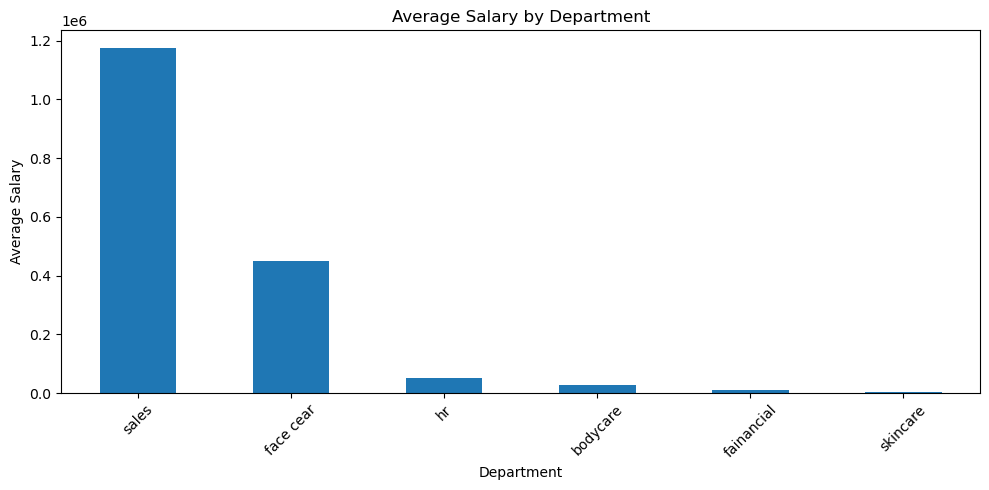

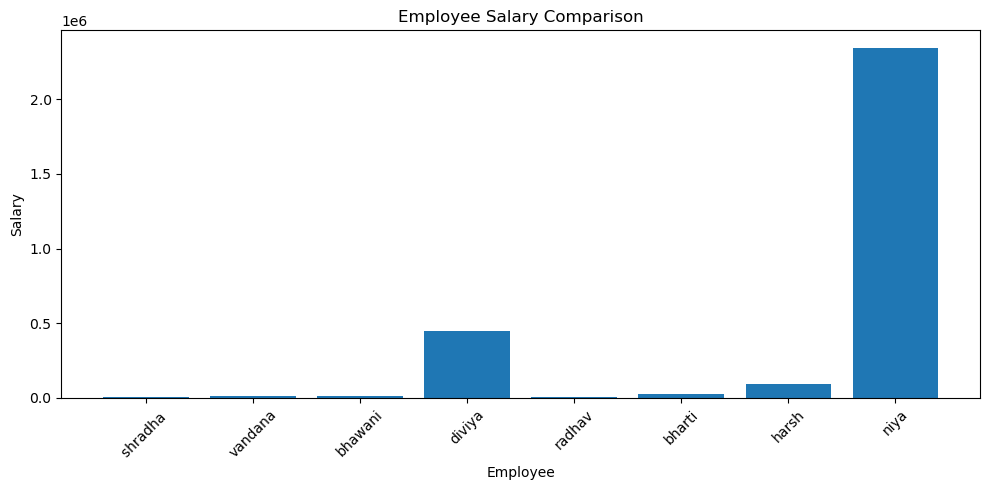

Employee charts created successfully! 📊


In [25]:
create_employee_charts(csv_file)

In [1]:
def create_employee_report(df):

    print("=" * 60)
    print("       PROFESSIONAL EMPLOYEE ANALYSIS REPORT")
    print("=" * 60)

    # Data Quality
    print("\nDATA QUALITY")
    print("-" * 60)
    print(f"Rows: {len(df)}")
    print(f"Columns: {len(df.columns)}")
    print(f"Duplicate rows: {df.duplicated().sum()}")
    print(f"Missing values: {df.isnull().sum().sum()}")

    # Salary KPIs
    print("\nSALARY KPIs")
    print("-" * 60)
    print(f"Total Salary: ₹{df['salary'].sum():,.2f}")
    print(f"Average Salary: ₹{df['salary'].mean():,.2f}")
    print(f"Highest Salary: ₹{df['salary'].max():,.2f}")
    print(f"Lowest Salary: ₹{df['salary'].min():,.2f}")

    # Top Employee
    top_employee = df.loc[df['salary'].idxmax(), 'name']

    print("\nTOP EMPLOYEE")
    print("-" * 60)
    print(f"Highest-paid employee: {top_employee}")

    # Department Analysis
    dept_avg = df.groupby("department")["salary"].mean()
    top_department = dept_avg.idxmax()
    top_department_salary = dept_avg.max()

    print("\nDEPARTMENT ANALYSIS")
    print("-" * 60)
    print(f"Highest average salary department: {top_department}")
    print(f"Average salary: ₹{top_department_salary:,.2f}")

    # Business Insights
    print("\nBUSINESS INSIGHTS")
    print("-" * 60)
    print(
        f"{top_department} has the highest average salary "
        f"at ₹{top_department_salary:,.2f}."
    )
    print(f"{top_employee} has the highest salary in the dataset.")

    print("\n" + "=" * 60)
    print("       Report completed successfully!")
    print("=" * 60)


In [4]:
import pandas as pd
import matplotlib.pyplot as plt

In [5]:
df = pd.DataFrame({
    "name": [
        "shradha",
        "vandana",
        "bhawani",
        "diviya",
        "radhav",
        "bharti",
        "harsh",
        "niya"
    ],
    "department": [
        "sales",
        "fainancial",
        "hr",
        "face cear",
        "skincare",
        "bodycare",
        "hr",
        "sales"
    ],
    "salary": [
        6000,
        9000,
        12000,
        450000,
        4500,
        27634,
        90000,
        2345678
    ]
})

print(df)

      name  department   salary
0  shradha       sales     6000
1  vandana  fainancial     9000
2  bhawani          hr    12000
3   diviya   face cear   450000
4   radhav    skincare     4500
5   bharti    bodycare    27634
6    harsh          hr    90000
7     niya       sales  2345678


In [6]:
create_employee_report(df)

       PROFESSIONAL EMPLOYEE ANALYSIS REPORT

DATA QUALITY
------------------------------------------------------------
Rows: 8
Columns: 3
Duplicate rows: 0
Missing values: 0

SALARY KPIs
------------------------------------------------------------
Total Salary: ₹2,944,812.00
Average Salary: ₹368,101.50
Highest Salary: ₹2,345,678.00
Lowest Salary: ₹4,500.00

TOP EMPLOYEE
------------------------------------------------------------
Highest-paid employee: niya

DEPARTMENT ANALYSIS
------------------------------------------------------------
Highest average salary department: sales
Average salary: ₹1,175,839.00

BUSINESS INSIGHTS
------------------------------------------------------------
sales has the highest average salary at ₹1,175,839.00.
niya has the highest salary in the dataset.

       Report completed successfully!


In [7]:
def detect_columns(df):

    numeric_columns = df.select_dtypes(include="number").columns.tolist()
    categorical_columns = df.select_dtypes(include="object").columns.tolist()

    print("=" * 60)
    print("        AUTOMATIC COLUMN DETECTION")
    print("=" * 60)

    print("\nNumeric Columns:")
    for col in numeric_columns:
        print(f"  • {col}")

    print("\nCategorical Columns:")
    for col in categorical_columns:
        print(f"  • {col}")

    print("\nColumn Detection Completed! ✅")

In [8]:
detect_columns(df)

        AUTOMATIC COLUMN DETECTION

Numeric Columns:
  • salary

Categorical Columns:
  • name
  • department

Column Detection Completed! ✅


In [9]:
def automatic_kpis(df):

    numeric_columns = df.select_dtypes(include="number").columns.tolist()

    print("=" * 60)
    print("             AUTOMATIC KPI REPORT")
    print("=" * 60)

    for col in numeric_columns:

        print(f"\nCOLUMN: {col}")
        print("-" * 60)

        print(f"Total: {df[col].sum():,.2f}")
        print(f"Average: {df[col].mean():,.2f}")
        print(f"Highest: {df[col].max():,.2f}")
        print(f"Lowest: {df[col].min():,.2f}")

    print("\n" + "=" * 60)
    print("Automatic KPI generation completed! ✅")
    print("=" * 60)

In [10]:
automatic_kpis(df)

             AUTOMATIC KPI REPORT

COLUMN: salary
------------------------------------------------------------
Total: 2,944,812.00
Average: 368,101.50
Highest: 2,345,678.00
Lowest: 4,500.00

Automatic KPI generation completed! ✅


In [11]:
def automatic_insights(df):

    print("=" * 60)
    print("          AUTOMATIC BUSINESS INSIGHTS")
    print("=" * 60)

    numeric_columns = df.select_dtypes(include="number").columns.tolist()
    categorical_columns = df.select_dtypes(include="object").columns.tolist()

    # Numeric insights
    for col in numeric_columns:

        highest_value = df[col].max()
        lowest_value = df[col].min()
        average_value = df[col].mean()

        highest_row = df.loc[df[col].idxmax()]

        print(f"\nINSIGHT FOR: {col}")
        print("-" * 60)

        print(
            f"Average {col}: {average_value:,.2f}"
        )

        print(
            f"Highest {col}: {highest_value:,.2f}"
        )

        print(
            f"Lowest {col}: {lowest_value:,.2f}"
        )

        # Find name/person associated with highest value
        name_columns = [
            c for c in categorical_columns
            if c.lower() in ["name", "employee", "customer", "product"]
        ]

        if name_columns:
            name_col = name_columns[0]

            print(
                f"Highest {col} belongs to "
                f"{highest_row[name_col]}."
            )

    # Categorical insights
    for col in categorical_columns:

        if col.lower() in ["name", "employee"]:
            continue

        print(f"\nCATEGORY INSIGHT: {col}")
        print("-" * 60)

        counts = df[col].value_counts()

        if len(counts) > 0:
            top_category = counts.index[0]
            top_count = counts.iloc[0]

            print(
                f"Most common {col}: "
                f"{top_category} ({top_count} records)."
            )

    print("\n" + "=" * 60)
    print("Automatic business insights completed! ✅")
    print("=" * 60)

In [12]:
automatic_insights(df)

          AUTOMATIC BUSINESS INSIGHTS

INSIGHT FOR: salary
------------------------------------------------------------
Average salary: 368,101.50
Highest salary: 2,345,678.00
Lowest salary: 4,500.00
Highest salary belongs to niya.

CATEGORY INSIGHT: department
------------------------------------------------------------
Most common department: sales (2 records).

Automatic business insights completed! ✅


In [13]:
def run_agent(df):

    print("\n")
    print("=" * 70)
    print("              🤖 AI DATA ANALYSIS AGENT")
    print("=" * 70)

    # 1. Column Detection
    detect_columns(df)

    # 2. Automatic KPIs
    automatic_kpis(df)

    # 3. Business Insights
    automatic_insights(df)

    # 4. Charts
    create_employee_charts(df)

    # 5. Professional Report
    create_employee_report(df)

    print("\n")
    print("=" * 70)
    print("        🎉 COMPLETE DATA ANALYSIS FINISHED!")
    print("=" * 70)

In [16]:
import matplotlib.pyplot as plt

def create_employee_charts(df):

    print("Creating Employee Charts...")
    print("=" * 60)

    # Department-wise Average Salary
    dept_salary = (
        df.groupby("department")["salary"]
        .mean()
        .sort_values(ascending=False)
    )

    plt.figure(figsize=(10, 5))
    dept_salary.plot(kind="bar")
    plt.title("Average Salary by Department")
    plt.xlabel("Department")
    plt.ylabel("Average Salary")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    # Employee-wise Salary
    plt.figure(figsize=(10, 5))
    plt.bar(df["name"], df["salary"])
    plt.title("Employee Salary Comparison")
    plt.xlabel("Employee")
    plt.ylabel("Salary")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    print("Employee charts created successfully! 📊")



              🤖 AI DATA ANALYSIS AGENT
        AUTOMATIC COLUMN DETECTION

Numeric Columns:
  • salary

Categorical Columns:
  • name
  • department

Column Detection Completed! ✅
             AUTOMATIC KPI REPORT

COLUMN: salary
------------------------------------------------------------
Total: 2,944,812.00
Average: 368,101.50
Highest: 2,345,678.00
Lowest: 4,500.00

Automatic KPI generation completed! ✅
          AUTOMATIC BUSINESS INSIGHTS

INSIGHT FOR: salary
------------------------------------------------------------
Average salary: 368,101.50
Highest salary: 2,345,678.00
Lowest salary: 4,500.00
Highest salary belongs to niya.

CATEGORY INSIGHT: department
------------------------------------------------------------
Most common department: sales (2 records).

Automatic business insights completed! ✅
Creating Employee Charts...


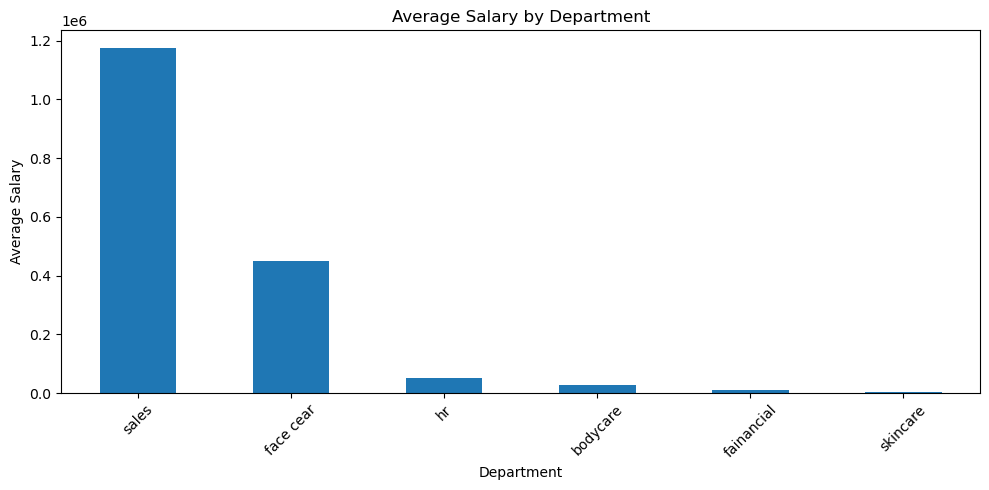

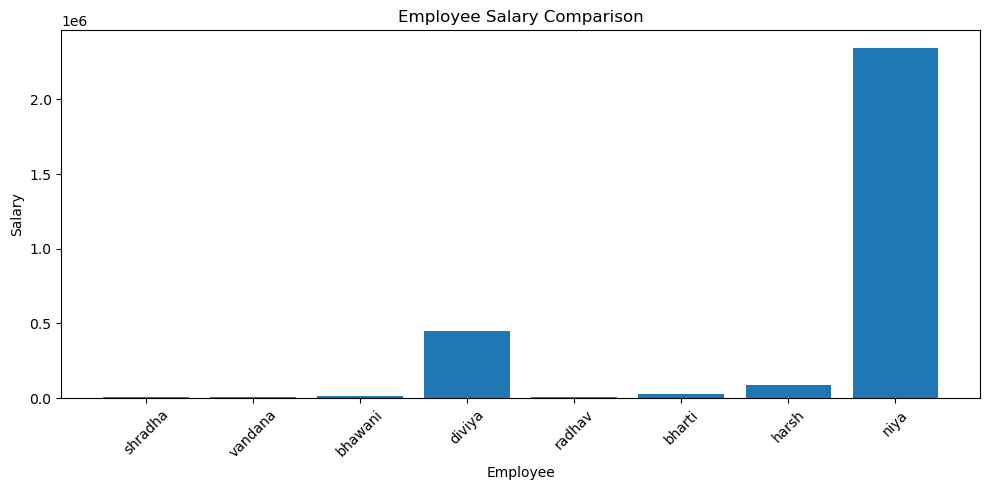

Employee charts created successfully! 📊
       PROFESSIONAL EMPLOYEE ANALYSIS REPORT

DATA QUALITY
------------------------------------------------------------
Rows: 8
Columns: 3
Duplicate rows: 0
Missing values: 0

SALARY KPIs
------------------------------------------------------------
Total Salary: ₹2,944,812.00
Average Salary: ₹368,101.50
Highest Salary: ₹2,345,678.00
Lowest Salary: ₹4,500.00

TOP EMPLOYEE
------------------------------------------------------------
Highest-paid employee: niya

DEPARTMENT ANALYSIS
------------------------------------------------------------
Highest average salary department: sales
Average salary: ₹1,175,839.00

BUSINESS INSIGHTS
------------------------------------------------------------
sales has the highest average salary at ₹1,175,839.00.
niya has the highest salary in the dataset.

       Report completed successfully!


        🎉 COMPLETE DATA ANALYSIS FINISHED!


In [17]:
run_agent(df)

In [18]:
import pandas as pd

def load_dataset(file_path):

    if file_path.lower().endswith(".csv"):
        df = pd.read_csv(file_path)

    elif file_path.lower().endswith((".xlsx", ".xls")):
        df = pd.read_excel(file_path)

    else:
        raise ValueError(
            "Unsupported file format. Please use CSV or Excel."
        )

    print("Dataset loaded successfully! ✅")
    print(f"Rows: {len(df)}")
    print(f"Columns: {len(df.columns)}")

    return df

In [19]:
print(type(df))
print(df.shape)
print(df.head())

<class 'pandas.core.frame.DataFrame'>
(8, 3)
      name  department  salary
0  shradha       sales    6000
1  vandana  fainancial    9000
2  bhawani          hr   12000
3   diviya   face cear  450000
4   radhav    skincare    4500


In [20]:
import os

print(os.getcwd())
print("\nFiles in this folder:")
print(os.listdir())

C:\Users\KAMAL DEWANGAN\Documents

Files in this folder:
['#1 Excel trick to earn Rs. 436 in just 1 hour (Merge Data).xlsx - Google Sheets.html', '#1 Excel trick to earn Rs. 436 in just 1 hour (Merge Data).xlsx - Google Sheets_files', '.ipynb_checkpoints', '14.xlsx', '15 formulas.xlsx', '15 p.xlsx', '15.xlsx', '2.xlsx', '2000.xlsx', '3.xlsx', '4.xlsx', '459.xlsx', '5.xlsx', '6 mounth data analyst studay plan.docx', '6 mouth staudy paln.docx', '875 earn.xlsx', 'advance excel.xlsx', 'AMAZON.pbix', 'analysis.docx', 'analysis.xlsx', 'BACIC FUNCTION.xlsx', 'bajabajaxcuuui.docx', 'Bhawani_Rajput_ppt.pptx', 'board apllya.pptx', 'Book.xlsx', 'Book1.xlsx', 'Book2.xlsx', 'Book9.xlsx', 'Bookdf.xlsx', 'calculation core.xlsx', 'class.sql', 'class.xlsx', 'classic_models_dataset', 'cleaning karna hai our beshboard banana hai.xlsx', 'Comprension.docx', 'convert pdf to excel pdf.xlsx', 'Copy of Ira_Edu-Tech-_MS_Excel_training_28_NOV(1).xlsx', 'copy_D24FC415-BCD7-49A1-B4F3-7CC3BCA1B0BF.MOV', 'cricket da

In [21]:
print(os.listdir())

['#1 Excel trick to earn Rs. 436 in just 1 hour (Merge Data).xlsx - Google Sheets.html', '#1 Excel trick to earn Rs. 436 in just 1 hour (Merge Data).xlsx - Google Sheets_files', '.ipynb_checkpoints', '14.xlsx', '15 formulas.xlsx', '15 p.xlsx', '15.xlsx', '2.xlsx', '2000.xlsx', '3.xlsx', '4.xlsx', '459.xlsx', '5.xlsx', '6 mounth data analyst studay plan.docx', '6 mouth staudy paln.docx', '875 earn.xlsx', 'advance excel.xlsx', 'AMAZON.pbix', 'analysis.docx', 'analysis.xlsx', 'BACIC FUNCTION.xlsx', 'bajabajaxcuuui.docx', 'Bhawani_Rajput_ppt.pptx', 'board apllya.pptx', 'Book.xlsx', 'Book1.xlsx', 'Book2.xlsx', 'Book9.xlsx', 'Bookdf.xlsx', 'calculation core.xlsx', 'class.sql', 'class.xlsx', 'classic_models_dataset', 'cleaning karna hai our beshboard banana hai.xlsx', 'Comprension.docx', 'convert pdf to excel pdf.xlsx', 'Copy of Ira_Edu-Tech-_MS_Excel_training_28_NOV(1).xlsx', 'copy_D24FC415-BCD7-49A1-B4F3-7CC3BCA1B0BF.MOV', 'cricket data.xlsx', 'csv.csv', 'Custom Office Templates', 'DATA ANA

In [22]:
print(os.listdir())

['#1 Excel trick to earn Rs. 436 in just 1 hour (Merge Data).xlsx - Google Sheets.html', '#1 Excel trick to earn Rs. 436 in just 1 hour (Merge Data).xlsx - Google Sheets_files', '.ipynb_checkpoints', '14.xlsx', '15 formulas.xlsx', '15 p.xlsx', '15.xlsx', '2.xlsx', '2000.xlsx', '3.xlsx', '4.xlsx', '459.xlsx', '5.xlsx', '6 mounth data analyst studay plan.docx', '6 mouth staudy paln.docx', '875 earn.xlsx', 'advance excel.xlsx', 'AMAZON.pbix', 'analysis.docx', 'analysis.xlsx', 'BACIC FUNCTION.xlsx', 'bajabajaxcuuui.docx', 'Bhawani_Rajput_ppt.pptx', 'board apllya.pptx', 'Book.xlsx', 'Book1.xlsx', 'Book2.xlsx', 'Book9.xlsx', 'Bookdf.xlsx', 'calculation core.xlsx', 'class.sql', 'class.xlsx', 'classic_models_dataset', 'cleaning karna hai our beshboard banana hai.xlsx', 'Comprension.docx', 'convert pdf to excel pdf.xlsx', 'Copy of Ira_Edu-Tech-_MS_Excel_training_28_NOV(1).xlsx', 'copy_D24FC415-BCD7-49A1-B4F3-7CC3BCA1B0BF.MOV', 'cricket data.xlsx', 'csv.csv', 'Custom Office Templates', 'DATA ANA

In [23]:
file_path = "csv.csv"

df = load_dataset(file_path)

print("\nFirst 5 rows:")
print(df.head())

Dataset loaded successfully! ✅
Rows: 8
Columns: 3

First 5 rows:
      name  department]  salary 
0  shradha        sales     6000
1   vandana  fainancial     9000
2   bhawani          hr    12000
3    diviya   face cear   450000
4    radhav    skincare     4500


In [26]:
import pandas as pd

def load_dataset(file_path):

    if file_path.lower().endswith(".csv"):
        df = pd.read_csv(file_path)

    elif file_path.lower().endswith((".xlsx", ".xls")):
        df = pd.read_excel(file_path)

    else:
        raise ValueError(
            "Unsupported file format. Please use CSV or Excel."
        )

    print("Dataset loaded successfully! ✅")
    print(f"Rows: {len(df)}")
    print(f"Columns: {len(df.columns)}")

    return df

In [27]:
file_path = "14.xlsx"

df_excel = load_dataset(file_path)

print("\nFirst 5 rows:")
print(df_excel.head())

Dataset loaded successfully! ✅
Rows: 51
Columns: 78

First 5 rows:
   Order_ID  Product     Category Region    Sales  Quantity  Unnamed: 6  \
0      1001   Laptop  Electronics  North  55000.0       2.0         NaN   
1      1002   Mobile  Electronics  South  25000.0       3.0         NaN   
2      1003    Chair    Furniture   East   7000.0       4.0         NaN   
3      1004    Table    Furniture   West  12000.0       2.0         NaN   
4      1005  Printer  Electronics  North  15000.0       1.0         NaN   

   Total Sales  Average Sales  Highest Sales   ...  Unnamed: 68  Unnamed: 69  \
0    1199100.0        23982.0         63000.0  ...          NaN          NaN   
1          NaN            NaN             NaN  ...          NaN          NaN   
2          NaN            NaN             NaN  ...          NaN          NaN   
3          NaN            NaN             NaN  ...          NaN          NaN   
4          NaN            NaN             NaN  ...          NaN          NaN   

 

In [29]:
df.columns = df.columns.str.strip().str.replace("]", "", regex=False)

print(df.columns.tolist())

['name', 'department', 'salary']


In [30]:
import matplotlib.pyplot as plt

def create_employee_charts(df):

    print("Creating Employee Charts...")
    print("=" * 60)

    # Clean column names
    df.columns = df.columns.str.strip().str.replace("]", "", regex=False)

    # Check required columns
    required_columns = ["department", "salary", "name"]

    for col in required_columns:
        if col not in df.columns:
            print(f"Chart skipped: '{col}' column not found.")
            return

    # Department-wise Average Salary
    dept_salary = (
        df.groupby("department")["salary"]
        .mean()
        .sort_values(ascending=False)
    )

    plt.figure(figsize=(10, 5))
    dept_salary.plot(kind="bar")
    plt.title("Average Salary by Department")
    plt.xlabel("Department")
    plt.ylabel("Average Salary")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    # Employee-wise Salary
    plt.figure(figsize=(10, 5))
    plt.bar(df["name"], df["salary"])
    plt.title("Employee Salary Comparison")
    plt.xlabel("Employee")
    plt.ylabel("Salary")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    print("Employee charts created successfully! 📊")



              🤖 AI DATA ANALYSIS AGENT
        AUTOMATIC COLUMN DETECTION

Numeric Columns:
  • salary

Categorical Columns:
  • name
  • department

Column Detection Completed! ✅
             AUTOMATIC KPI REPORT

COLUMN: salary
------------------------------------------------------------
Total: 2,944,812.00
Average: 368,101.50
Highest: 2,345,678.00
Lowest: 4,500.00

Automatic KPI generation completed! ✅
          AUTOMATIC BUSINESS INSIGHTS

INSIGHT FOR: salary
------------------------------------------------------------
Average salary: 368,101.50
Highest salary: 2,345,678.00
Lowest salary: 4,500.00
Highest salary belongs to niya.

CATEGORY INSIGHT: department
------------------------------------------------------------
Most common department: sales (2 records).

Automatic business insights completed! ✅
Creating Employee Charts...


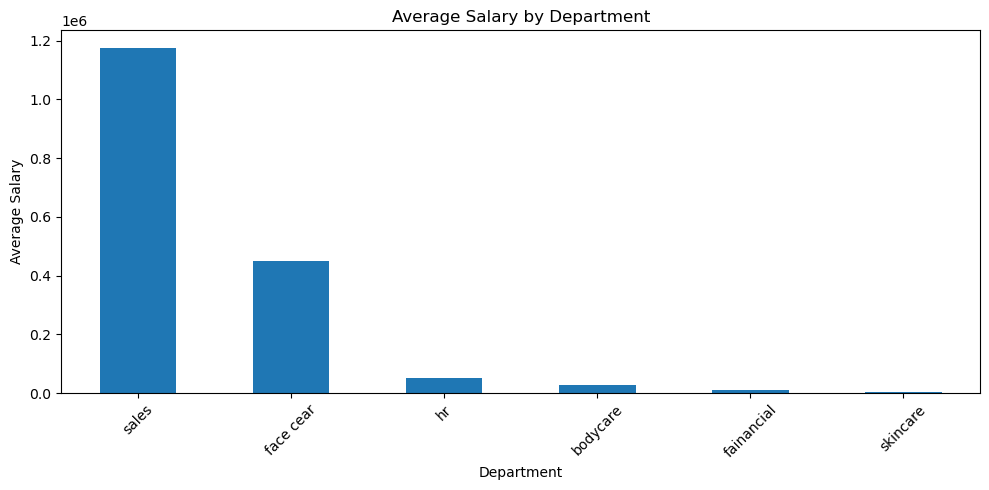

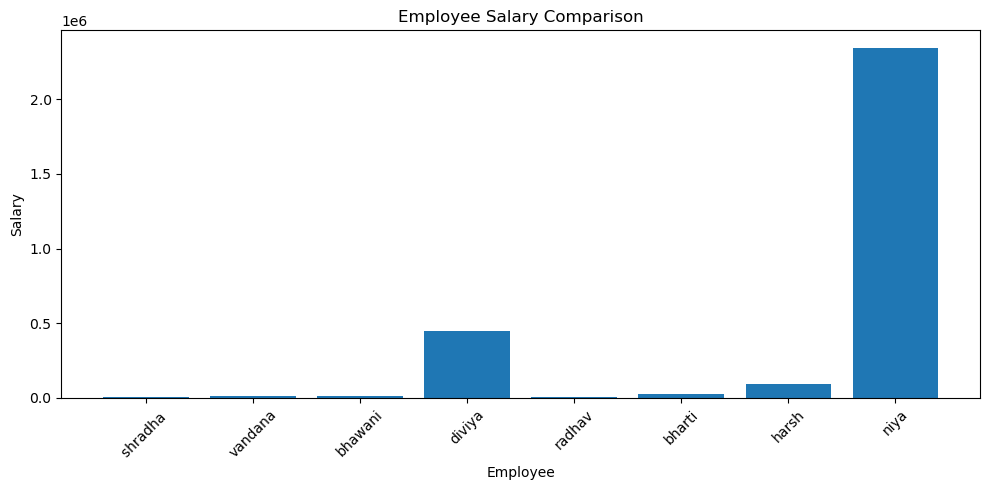

Employee charts created successfully! 📊
       PROFESSIONAL EMPLOYEE ANALYSIS REPORT

DATA QUALITY
------------------------------------------------------------
Rows: 8
Columns: 3
Duplicate rows: 0
Missing values: 0

SALARY KPIs
------------------------------------------------------------
Total Salary: ₹2,944,812.00
Average Salary: ₹368,101.50
Highest Salary: ₹2,345,678.00
Lowest Salary: ₹4,500.00

TOP EMPLOYEE
------------------------------------------------------------
Highest-paid employee: niya

DEPARTMENT ANALYSIS
------------------------------------------------------------
Highest average salary department: sales
Average salary: ₹1,175,839.00

BUSINESS INSIGHTS
------------------------------------------------------------
sales has the highest average salary at ₹1,175,839.00.
niya has the highest salary in the dataset.

       Report completed successfully!


        🎉 COMPLETE DATA ANALYSIS FINISHED!


In [31]:
run_agent(df)

In [32]:
def clean_columns(df):

    df = df.copy()

    # Remove extra spaces
    df.columns = df.columns.str.strip()

    # Remove unwanted characters
    df.columns = (
        df.columns
        .str.replace("]", "", regex=False)
        .str.replace("[", "", regex=False)
        .str.replace("(", "", regex=False)
        .str.replace(")", "", regex=False)
    )

    # Convert column names to lowercase
    df.columns = df.columns.str.lower()

    print("Column names cleaned successfully! ✅")
    print("Clean columns:")
    print(df.columns.tolist())

    return df

In [33]:

df = clean_columns(df)

Column names cleaned successfully! ✅
Clean columns:
['name', 'department', 'salary']


In [34]:
df = clean_columns(df)

Column names cleaned successfully! ✅
Clean columns:
['name', 'department', 'salary']


In [35]:
def run_agent(df):

    print("\n")
    print("=" * 70)
    print("              🤖 AI DATA ANALYSIS AGENT")
    print("=" * 70)

    # Step 1: Clean columns
    df = clean_columns(df)

    # Step 2: Column Detection
    detect_columns(df)

    # Step 3: Automatic KPIs
    automatic_kpis(df)

    # Step 4: Business Insights
    automatic_insights(df)

    # Step 5: Charts
    create_employee_charts(df)

    # Step 6: Professional Report
    create_employee_report(df)

    print("\n")
    print("=" * 70)
    print("        🎉 COMPLETE DATA ANALYSIS FINISHED!")
    print("=" * 70)

    return df



              🤖 AI DATA ANALYSIS AGENT
Column names cleaned successfully! ✅
Clean columns:
['name', 'department', 'salary']
        AUTOMATIC COLUMN DETECTION

Numeric Columns:
  • salary

Categorical Columns:
  • name
  • department

Column Detection Completed! ✅
             AUTOMATIC KPI REPORT

COLUMN: salary
------------------------------------------------------------
Total: 2,944,812.00
Average: 368,101.50
Highest: 2,345,678.00
Lowest: 4,500.00

Automatic KPI generation completed! ✅
          AUTOMATIC BUSINESS INSIGHTS

INSIGHT FOR: salary
------------------------------------------------------------
Average salary: 368,101.50
Highest salary: 2,345,678.00
Lowest salary: 4,500.00
Highest salary belongs to niya.

CATEGORY INSIGHT: department
------------------------------------------------------------
Most common department: sales (2 records).

Automatic business insights completed! ✅
Creating Employee Charts...


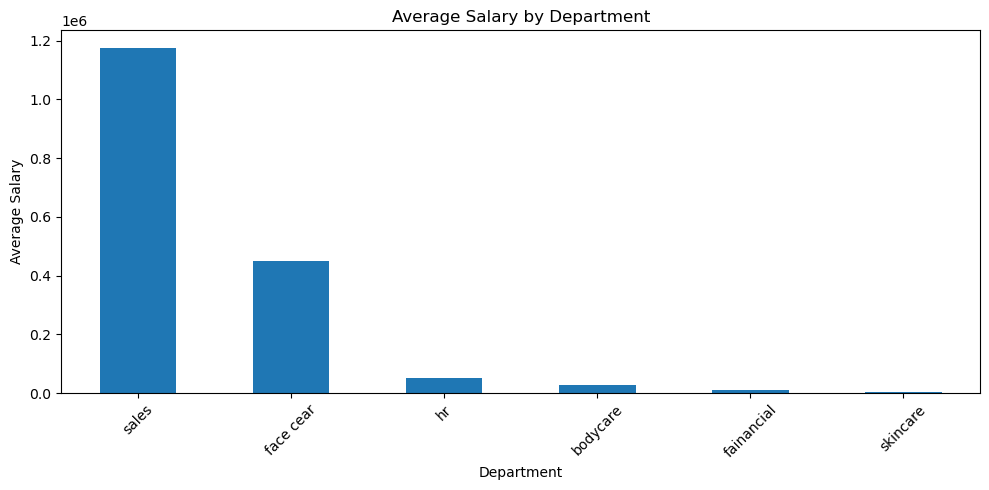

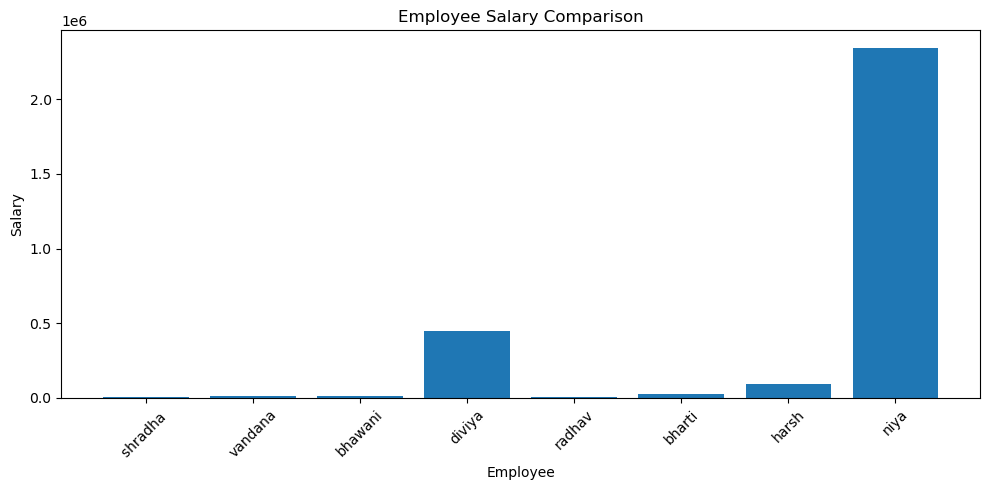

Employee charts created successfully! 📊
       PROFESSIONAL EMPLOYEE ANALYSIS REPORT

DATA QUALITY
------------------------------------------------------------
Rows: 8
Columns: 3
Duplicate rows: 0
Missing values: 0

SALARY KPIs
------------------------------------------------------------
Total Salary: ₹2,944,812.00
Average Salary: ₹368,101.50
Highest Salary: ₹2,345,678.00
Lowest Salary: ₹4,500.00

TOP EMPLOYEE
------------------------------------------------------------
Highest-paid employee: niya

DEPARTMENT ANALYSIS
------------------------------------------------------------
Highest average salary department: sales
Average salary: ₹1,175,839.00

BUSINESS INSIGHTS
------------------------------------------------------------
sales has the highest average salary at ₹1,175,839.00.
niya has the highest salary in the dataset.

       Report completed successfully!


        🎉 COMPLETE DATA ANALYSIS FINISHED!


In [36]:
df = run_agent(df)

Dataset loaded successfully! ✅
Rows: 8
Columns: 3


              🤖 AI DATA ANALYSIS AGENT
Column names cleaned successfully! ✅
Clean columns:
['name', 'department', 'salary']
        AUTOMATIC COLUMN DETECTION

Numeric Columns:
  • salary

Categorical Columns:
  • name
  • department

Column Detection Completed! ✅
             AUTOMATIC KPI REPORT

COLUMN: salary
------------------------------------------------------------
Total: 2,944,812.00
Average: 368,101.50
Highest: 2,345,678.00
Lowest: 4,500.00

Automatic KPI generation completed! ✅
          AUTOMATIC BUSINESS INSIGHTS

INSIGHT FOR: salary
------------------------------------------------------------
Average salary: 368,101.50
Highest salary: 2,345,678.00
Lowest salary: 4,500.00
Highest salary belongs to niya.

CATEGORY INSIGHT: department
------------------------------------------------------------
Most common department: sales (2 records).

Automatic business insights completed! ✅
Creating Employee Charts...


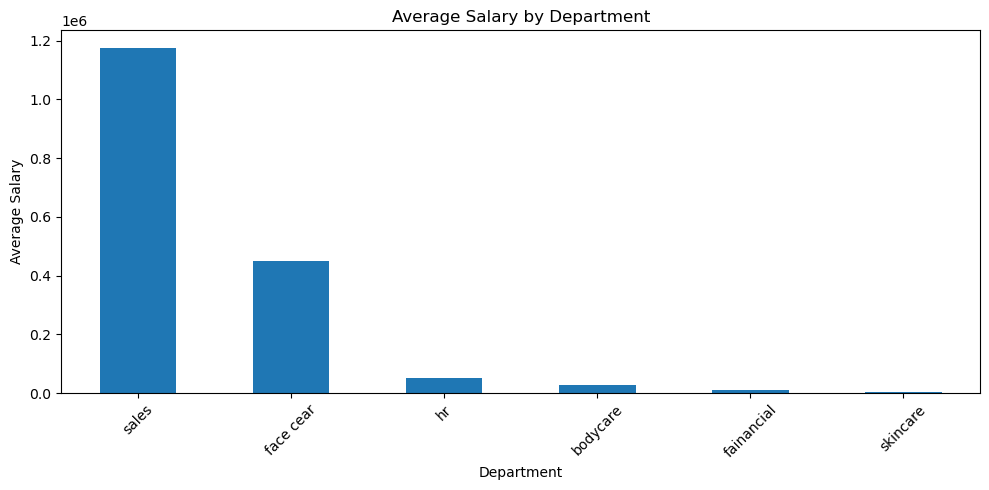

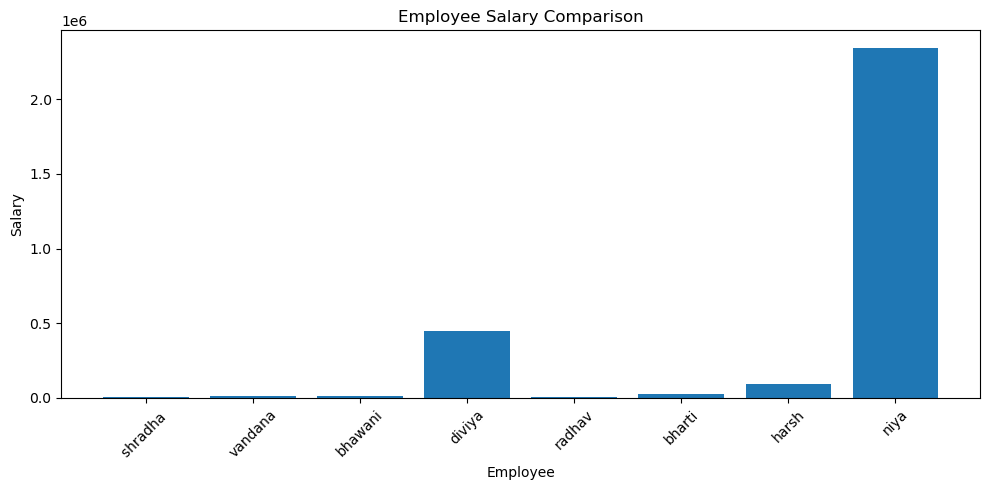

Employee charts created successfully! 📊
       PROFESSIONAL EMPLOYEE ANALYSIS REPORT

DATA QUALITY
------------------------------------------------------------
Rows: 8
Columns: 3
Duplicate rows: 0
Missing values: 0

SALARY KPIs
------------------------------------------------------------
Total Salary: ₹2,944,812.00
Average Salary: ₹368,101.50
Highest Salary: ₹2,345,678.00
Lowest Salary: ₹4,500.00

TOP EMPLOYEE
------------------------------------------------------------
Highest-paid employee: niya

DEPARTMENT ANALYSIS
------------------------------------------------------------
Highest average salary department: sales
Average salary: ₹1,175,839.00

BUSINESS INSIGHTS
------------------------------------------------------------
sales has the highest average salary at ₹1,175,839.00.
niya has the highest salary in the dataset.

       Report completed successfully!


        🎉 COMPLETE DATA ANALYSIS FINISHED!


In [37]:
df = load_dataset("csv.csv")
df = run_agent(df)

In [39]:
def analyze_file(file_path):

    print("\n")
    print("=" * 70)
    print("             🚀 AUTOMATIC DATA ANALYZER")
    print("=" * 70)

    # Load CSV / Excel
    df = load_dataset(file_path)

    print("\nDataset loaded. Starting analysis...\n")

    # Run complete agent
    df = run_agent(df)

    return df



             🚀 AUTOMATIC DATA ANALYZER
Dataset loaded successfully! ✅
Rows: 8
Columns: 3

Dataset loaded. Starting analysis...



              🤖 AI DATA ANALYSIS AGENT
Column names cleaned successfully! ✅
Clean columns:
['name', 'department', 'salary']
        AUTOMATIC COLUMN DETECTION

Numeric Columns:
  • salary

Categorical Columns:
  • name
  • department

Column Detection Completed! ✅
             AUTOMATIC KPI REPORT

COLUMN: salary
------------------------------------------------------------
Total: 2,944,812.00
Average: 368,101.50
Highest: 2,345,678.00
Lowest: 4,500.00

Automatic KPI generation completed! ✅
          AUTOMATIC BUSINESS INSIGHTS

INSIGHT FOR: salary
------------------------------------------------------------
Average salary: 368,101.50
Highest salary: 2,345,678.00
Lowest salary: 4,500.00
Highest salary belongs to niya.

CATEGORY INSIGHT: department
------------------------------------------------------------
Most common department: sales (2 records).

Automat

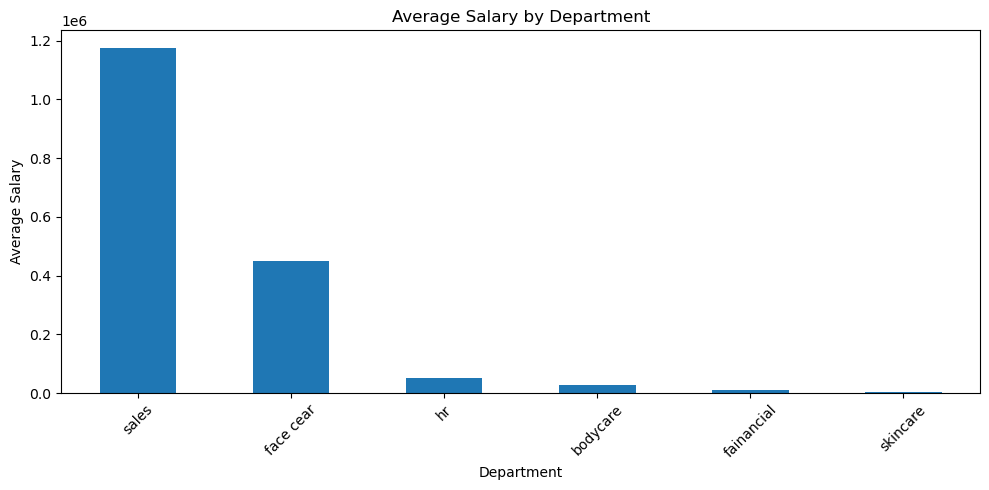

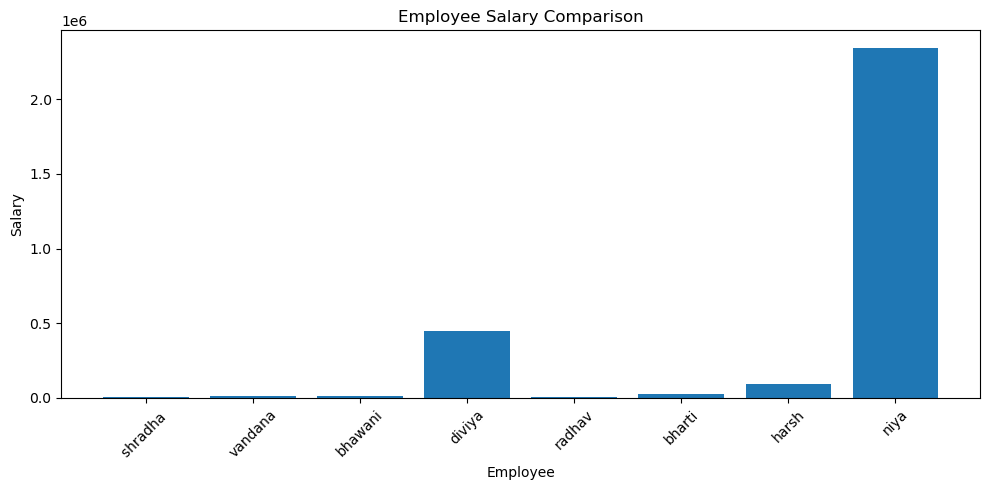

Employee charts created successfully! 📊
       PROFESSIONAL EMPLOYEE ANALYSIS REPORT

DATA QUALITY
------------------------------------------------------------
Rows: 8
Columns: 3
Duplicate rows: 0
Missing values: 0

SALARY KPIs
------------------------------------------------------------
Total Salary: ₹2,944,812.00
Average Salary: ₹368,101.50
Highest Salary: ₹2,345,678.00
Lowest Salary: ₹4,500.00

TOP EMPLOYEE
------------------------------------------------------------
Highest-paid employee: niya

DEPARTMENT ANALYSIS
------------------------------------------------------------
Highest average salary department: sales
Average salary: ₹1,175,839.00

BUSINESS INSIGHTS
------------------------------------------------------------
sales has the highest average salary at ₹1,175,839.00.
niya has the highest salary in the dataset.

       Report completed successfully!


        🎉 COMPLETE DATA ANALYSIS FINISHED!


In [40]:
df = analyze_file("csv.csv")



             🚀 AUTOMATIC DATA ANALYZER
Dataset loaded successfully! ✅
Rows: 8
Columns: 3

Dataset loaded. Starting analysis...



              🤖 AI DATA ANALYSIS AGENT
Column names cleaned successfully! ✅
Clean columns:
['name', 'department', 'salary']
        AUTOMATIC COLUMN DETECTION

Numeric Columns:
  • salary

Categorical Columns:
  • name
  • department

Column Detection Completed! ✅
             AUTOMATIC KPI REPORT

COLUMN: salary
------------------------------------------------------------
Total: 2,944,812.00
Average: 368,101.50
Highest: 2,345,678.00
Lowest: 4,500.00

Automatic KPI generation completed! ✅
          AUTOMATIC BUSINESS INSIGHTS

INSIGHT FOR: salary
------------------------------------------------------------
Average salary: 368,101.50
Highest salary: 2,345,678.00
Lowest salary: 4,500.00
Highest salary belongs to niya.

CATEGORY INSIGHT: department
------------------------------------------------------------
Most common department: sales (2 records).

Automat

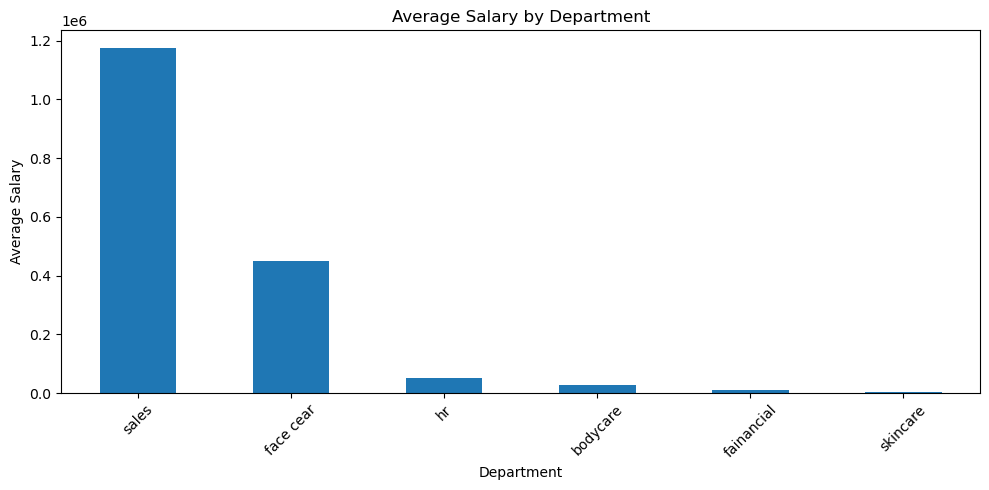

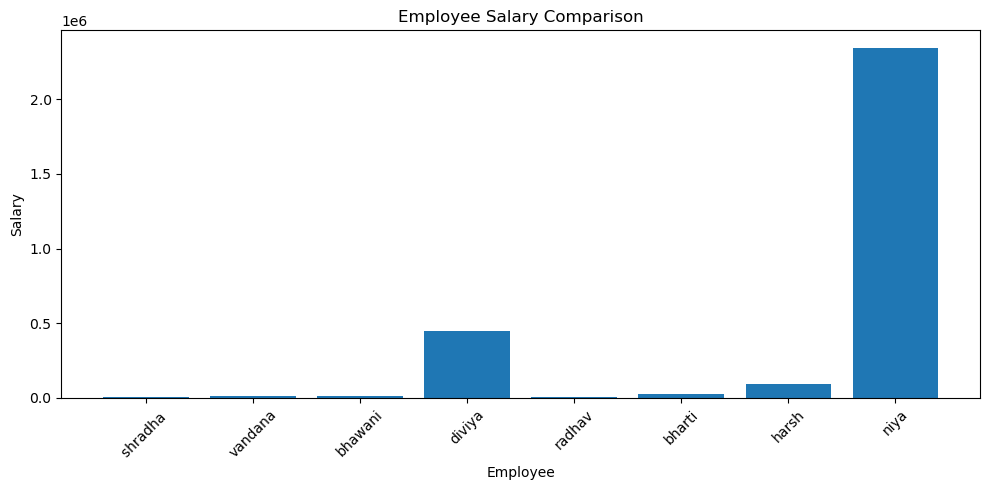

Employee charts created successfully! 📊
       PROFESSIONAL EMPLOYEE ANALYSIS REPORT

DATA QUALITY
------------------------------------------------------------
Rows: 8
Columns: 3
Duplicate rows: 0
Missing values: 0

SALARY KPIs
------------------------------------------------------------
Total Salary: ₹2,944,812.00
Average Salary: ₹368,101.50
Highest Salary: ₹2,345,678.00
Lowest Salary: ₹4,500.00

TOP EMPLOYEE
------------------------------------------------------------
Highest-paid employee: niya

DEPARTMENT ANALYSIS
------------------------------------------------------------
Highest average salary department: sales
Average salary: ₹1,175,839.00

BUSINESS INSIGHTS
------------------------------------------------------------
sales has the highest average salary at ₹1,175,839.00.
niya has the highest salary in the dataset.

       Report completed successfully!


        🎉 COMPLETE DATA ANALYSIS FINISHED!


In [41]:
df = analyze_file("csv.csv")

In [42]:
df_excel = analyze_file("14.xlsx")



             🚀 AUTOMATIC DATA ANALYZER
Dataset loaded successfully! ✅
Rows: 51
Columns: 78

Dataset loaded. Starting analysis...



              🤖 AI DATA ANALYSIS AGENT
Column names cleaned successfully! ✅
Clean columns:
['order_id', 'product', 'category', 'region', 'sales', 'quantity', 'unnamed: 6', 'total sales', 'average sales', 'highest sales', 'lowest sales', 'electronics category total sales', 'furniture category total sales', 'north region total sales', 'if', 'product laptop total entries', 'south region average sales', 'total quantity', 'unnamed: 18', 'unnamed: 19', 'unnamed: 20', 'unnamed: 21', 'unnamed: 22', 'unnamed: 23', 'unnamed: 24', 'unnamed: 25', 'unnamed: 26', 'unnamed: 27', 'unnamed: 28', 'unnamed: 29', 'unnamed: 30', 'unnamed: 31', 'unnamed: 32', 'unnamed: 33', 'unnamed: 34', 'unnamed: 35', 'unnamed: 36', 'unnamed: 37', 'unnamed: 38', 'unnamed: 39', 'unnamed: 40', 'unnamed: 41', 'unnamed: 42', 'unnamed: 43', 'unnamed: 44', 'unnamed: 45', 'unnamed: 46', 'unnamed: 

C:\Users\KAMAL DEWANGAN\AppData\Local\Temp\ipykernel_9400\2752002589.py:17: FutureWarning: The behavior of Series.idxmax with all-NA values, or any-NA and skipna=False, is deprecated. In a future version this will raise ValueError
  highest_row = df.loc[df[col].idxmax()]


KeyError: nan

In [43]:
def detect_dataset_type(df):

    columns = [col.lower().strip() for col in df.columns]

    if "salary" in columns and ("name" in columns or "employee" in columns):
        dataset_type = "Employee Dataset"

    elif "sales" in columns or "revenue" in columns:
        dataset_type = "Sales Dataset"

    elif "price" in columns and ("product" in columns or "item" in columns):
        dataset_type = "Product Dataset"

    else:
        dataset_type = "Unknown Dataset"

    print("=" * 60)
    print("        DATASET TYPE DETECTION")
    print("=" * 60)
    print(f"Detected Dataset: {dataset_type}")
    print("=" * 60)

    return dataset_type

In [44]:
detect_dataset_type(df_excel)

        DATASET TYPE DETECTION
Detected Dataset: Sales Dataset


'Sales Dataset'

In [45]:
def sales_analysis(df):

    print("=" * 60)
    print("           SALES DATASET ANALYSIS")
    print("=" * 60)

    # Clean column names
    df = df.copy()
    df.columns = df.columns.str.strip().str.lower()

    print("\nDATA QUALITY")
    print("-" * 60)
    print(f"Rows: {len(df)}")
    print(f"Columns: {len(df.columns)}")
    print(f"Duplicate rows: {df.duplicated().sum()}")
    print(f"Missing values: {df.isnull().sum().sum()}")

    # Find numeric columns
    numeric_columns = df.select_dtypes(include="number").columns.tolist()

    print("\nNUMERIC COLUMNS")
    print("-" * 60)

    for col in numeric_columns:
        print(f"• {col}")

    # Sales / Revenue KPI
    sales_column = None

    for col in numeric_columns:
        if col in ["sales", "revenue", "amount", "total_sales"]:
            sales_column = col
            break

    if sales_column:

        print("\nSALES KPIs")
        print("-" * 60)
        print(f"Total Sales: {df[sales_column].sum():,.2f}")
        print(f"Average Sales: {df[sales_column].mean():,.2f}")
        print(f"Highest Sale: {df[sales_column].max():,.2f}")
        print(f"Lowest Sale: {df[sales_column].min():,.2f}")

    print("\n" + "=" * 60)
    print("Sales analysis completed successfully! ✅")
    print("=" * 60)

In [46]:
sales_analysis(df_excel)

           SALES DATASET ANALYSIS

DATA QUALITY
------------------------------------------------------------
Rows: 51
Columns: 78
Duplicate rows: 0
Missing values: 3601

NUMERIC COLUMNS
------------------------------------------------------------
• order_id
• sales
• quantity
• unnamed: 6
• total sales
• average sales
• highest sales
• lowest sales
• electronics category total sales
• furniture category total sales
• north region total sales
• product laptop total entries
• south region average sales
• total quantity
• unnamed: 18
• unnamed: 20
• unnamed: 21
• unnamed: 22
• unnamed: 23
• unnamed: 24
• unnamed: 25
• unnamed: 26
• unnamed: 27
• unnamed: 28
• unnamed: 29
• unnamed: 30
• unnamed: 31
• unnamed: 32
• unnamed: 33
• unnamed: 34
• unnamed: 35
• unnamed: 36
• unnamed: 37
• unnamed: 38
• unnamed: 39
• unnamed: 40
• unnamed: 41
• unnamed: 42
• unnamed: 43
• unnamed: 44
• unnamed: 45
• unnamed: 46
• unnamed: 47
• unnamed: 48
• unnamed: 49
• unnamed: 50
• unnamed: 51
• unnamed: 52
•

In [47]:
def clean_sales_data(df):

    df = df.copy()

    # Clean column names
    df.columns = (
        df.columns
        .str.strip()
        .str.lower()
    )

    # Remove Unnamed columns
    df = df.loc[
        :,
        ~df.columns.str.startswith("unnamed")
    ]

    # Remove completely empty rows
    df = df.dropna(how="all")

    # Remove completely empty columns
    df = df.dropna(axis=1, how="all")

    print("=" * 60)
    print("        SMART SALES DATA CLEANING")
    print("=" * 60)

    print(f"\nRows after cleaning: {len(df)}")
    print(f"Columns after cleaning: {len(df.columns)}")

    print("\nRemaining Columns:")
    for col in df.columns:
        print(f"• {col}")

    print("\nSales data cleaning completed! ✅")
    print("=" * 60)

    return df

In [48]:
df_sales_clean = clean_sales_data(df_excel)

        SMART SALES DATA CLEANING

Rows after cleaning: 51
Columns after cleaning: 17

Remaining Columns:
• order_id
• product
• category
• region
• sales
• quantity
• total sales
• average sales
• highest sales
• lowest sales
• electronics category total sales
• furniture category total sales
• north region total sales
• if
• product laptop total entries
• south region average sales
• total quantity

Sales data cleaning completed! ✅


In [49]:
def detect_sales_columns(df):

    print("=" * 60)
    print("        SALES COLUMN DETECTION")
    print("=" * 60)

    columns = df.columns.tolist()

    # Main business columns
    business_columns = []

    keywords = [
        "order",
        "product",
        "category",
        "region",
        "customer",
        "sales",
        "quantity",
        "price",
        "date"
    ]

    for col in columns:

        # Skip columns that look like pre-calculated reports
        if any(word in col for word in [
            "total",
            "average",
            "highest",
            "lowest",
            "entries"
        ]):
            continue

        if col == "if":
            continue

        if any(keyword in col for keyword in keywords):
            business_columns.append(col)

    print("\nUseful Business Columns:")

    for col in business_columns:
        print(f"• {col}")

    print("\n" + "=" * 60)
    print("Sales column detection completed! ✅")
    print("=" * 60)

    return business_columns

In [50]:
sales_columns = detect_sales_columns(df_sales_clean)

        SALES COLUMN DETECTION

Useful Business Columns:
• order_id
• product
• category
• region
• sales
• quantity

Sales column detection completed! ✅


In [51]:
def smart_sales_kpis(df):

    print("=" * 60)
    print("             SMART SALES KPIs")
    print("=" * 60)

    # Total sales
    total_sales = df["sales"].sum()

    # Average sales
    average_sales = df["sales"].mean()

    # Highest sale
    highest_sale = df["sales"].max()

    # Lowest sale
    lowest_sale = df["sales"].min()

    # Total quantity
    total_quantity = df["quantity"].sum()

    # Number of orders
    total_orders = df["order_id"].nunique()

    print("\nSALES PERFORMANCE")
    print("-" * 60)

    print(f"Total Sales: ₹{total_sales:,.2f}")
    print(f"Average Sale: ₹{average_sales:,.2f}")
    print(f"Highest Sale: ₹{highest_sale:,.2f}")
    print(f"Lowest Sale: ₹{lowest_sale:,.2f}")

    print("\nORDER & QUANTITY")
    print("-" * 60)

    print(f"Total Orders: {total_orders}")
    print(f"Total Quantity Sold: {total_quantity}")

    # Top product
    if "product" in df.columns:

        product_sales = (
            df.groupby("product")["sales"]
            .sum()
            .sort_values(ascending=False)
        )

        top_product = product_sales.index[0]
        top_product_sales = product_sales.iloc[0]

        print("\nTOP PRODUCT")
        print("-" * 60)

        print(f"Top Product: {top_product}")
        print(f"Product Sales: ₹{top_product_sales:,.2f}")

    # Top region
    if "region" in df.columns:

        region_sales = (
            df.groupby("region")["sales"]
            .sum()
            .sort_values(ascending=False)
        )

        top_region = region_sales.index[0]
        top_region_sales = region_sales.iloc[0]

        print("\nTOP REGION")
        print("-" * 60)

        print(f"Top Region: {top_region}")
        print(f"Region Sales: ₹{top_region_sales:,.2f}")

    print("\n" + "=" * 60)
    print("Smart Sales KPI generation completed! ✅")
    print("=" * 60)

In [52]:
smart_sales_kpis(df_sales_clean)

             SMART SALES KPIs

SALES PERFORMANCE
------------------------------------------------------------
Total Sales: ₹1,199,100.00
Average Sale: ₹23,982.00
Highest Sale: ₹63,000.00
Lowest Sale: ₹7,000.00

ORDER & QUANTITY
------------------------------------------------------------
Total Orders: 51
Total Quantity Sold: 121.0

TOP PRODUCT
------------------------------------------------------------
Top Product: Laptop
Product Sales: ₹592,000.00

TOP REGION
------------------------------------------------------------
Top Region: South
Region Sales: ₹343,500.00

Smart Sales KPI generation completed! ✅


In [53]:
import matplotlib.pyplot as plt

def create_sales_charts(df):

    print("=" * 60)
    print("             SALES CHARTS")
    print("=" * 60)

    # 1. Sales by Product
    product_sales = (
        df.groupby("product")["sales"]
        .sum()
        .sort_values(ascending=False)
    )

    plt.figure(figsize=(10, 5))
    product_sales.plot(kind="bar")
    plt.title("Sales by Product")
    plt.xlabel("Product")
    plt.ylabel("Sales")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    # 2. Sales by Region
    region_sales = (
        df.groupby("region")["sales"]
        .sum()
        .sort_values(ascending=False)
    )

    plt.figure(figsize=(10, 5))
    region_sales.plot(kind="bar")
    plt.title("Sales by Region")
    plt.xlabel("Region")
    plt.ylabel("Sales")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    # 3. Sales by Category
    category_sales = (
        df.groupby("category")["sales"]
        .sum()
        .sort_values(ascending=False)
    )

    plt.figure(figsize=(10, 5))
    category_sales.plot(kind="bar")
    plt.title("Sales by Category")
    plt.xlabel("Category")
    plt.ylabel("Sales")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    print("Sales charts created successfully! 📊")

             SALES CHARTS


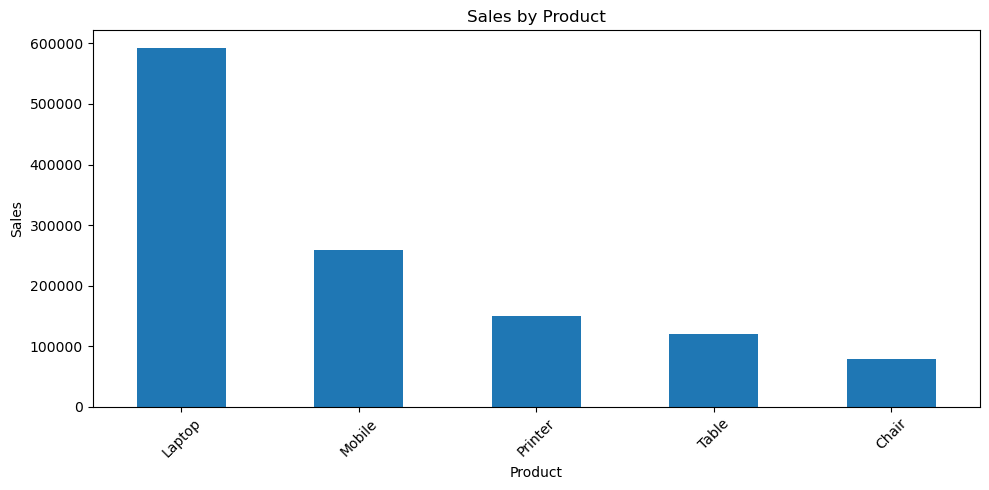

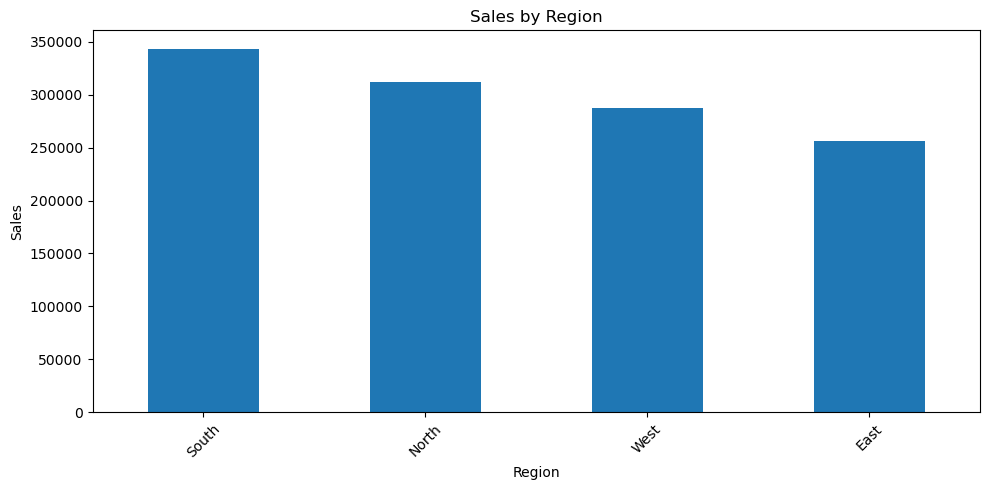

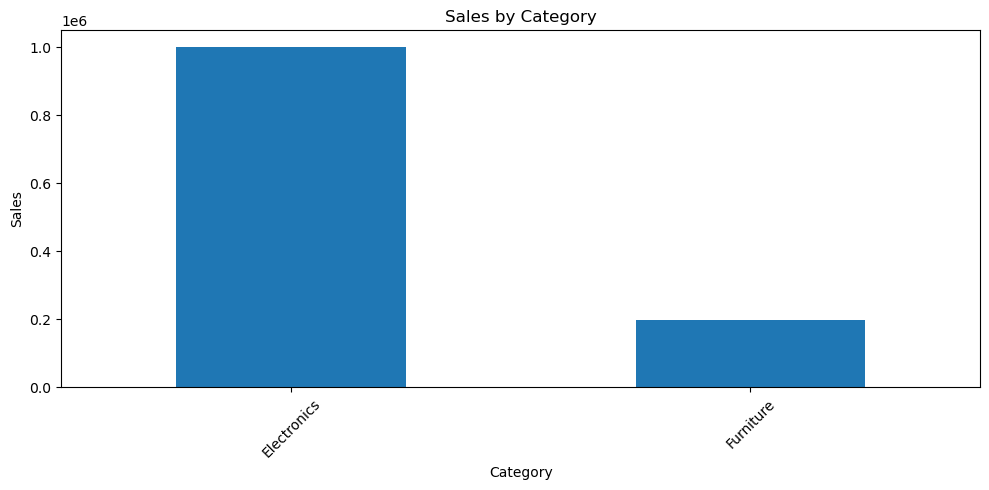

Sales charts created successfully! 📊


In [54]:
create_sales_charts(df_sales_clean)

In [55]:
def sales_business_insights(df):

    print("=" * 60)
    print("          SALES BUSINESS INSIGHTS")
    print("=" * 60)

    # Product analysis
    product_sales = (
        df.groupby("product")["sales"]
        .sum()
        .sort_values(ascending=False)
    )

    top_product = product_sales.index[0]
    top_product_sales = product_sales.iloc[0]

    # Region analysis
    region_sales = (
        df.groupby("region")["sales"]
        .sum()
        .sort_values(ascending=False)
    )

    top_region = region_sales.index[0]
    top_region_sales = region_sales.iloc[0]

    # Category analysis
    category_sales = (
        df.groupby("category")["sales"]
        .sum()
        .sort_values(ascending=False)
    )

    top_category = category_sales.index[0]
    top_category_sales = category_sales.iloc[0]

    lowest_category = category_sales.index[-1]
    lowest_category_sales = category_sales.iloc[-1]

    # Insights

    print("\nPRODUCT INSIGHT")
    print("-" * 60)

    print(
        f"{top_product} is the top-performing product "
        f"with sales of ₹{top_product_sales:,.2f}."
    )

    print("\nREGION INSIGHT")
    print("-" * 60)

    print(
        f"{top_region} is the highest-performing region "
        f"with sales of ₹{top_region_sales:,.2f}."
    )

    print("\nCATEGORY INSIGHT")
    print("-" * 60)

    print(
        f"{top_category} is the strongest category "
        f"with sales of ₹{top_category_sales:,.2f}."
    )

    print(
        f"{lowest_category} is the lowest-performing category "
        f"with sales of ₹{lowest_category_sales:,.2f}."
    )

    print("\nBUSINESS RECOMMENDATION")
    print("-" * 60)

    print(
        f"Focus more marketing and inventory on {top_product} "
        f"because it generates the highest sales."
    )

    print(
        f"Review the performance of {lowest_category} "
        f"and identify opportunities to improve its sales."
    )

    print("\n" + "=" * 60)
    print("Sales business insights completed! ✅")
    print("=" * 60)

In [56]:
sales_business_insights(df_sales_clean)

          SALES BUSINESS INSIGHTS

PRODUCT INSIGHT
------------------------------------------------------------
Laptop is the top-performing product with sales of ₹592,000.00.

REGION INSIGHT
------------------------------------------------------------
South is the highest-performing region with sales of ₹343,500.00.

CATEGORY INSIGHT
------------------------------------------------------------
Electronics is the strongest category with sales of ₹1,000,200.00.
Furniture is the lowest-performing category with sales of ₹198,900.00.

BUSINESS RECOMMENDATION
------------------------------------------------------------
Focus more marketing and inventory on Laptop because it generates the highest sales.
Review the performance of Furniture and identify opportunities to improve its sales.

Sales business insights completed! ✅


In [57]:
analyze_file("14.xlsx")



             🚀 AUTOMATIC DATA ANALYZER
Dataset loaded successfully! ✅
Rows: 51
Columns: 78

Dataset loaded. Starting analysis...



              🤖 AI DATA ANALYSIS AGENT
Column names cleaned successfully! ✅
Clean columns:
['order_id', 'product', 'category', 'region', 'sales', 'quantity', 'unnamed: 6', 'total sales', 'average sales', 'highest sales', 'lowest sales', 'electronics category total sales', 'furniture category total sales', 'north region total sales', 'if', 'product laptop total entries', 'south region average sales', 'total quantity', 'unnamed: 18', 'unnamed: 19', 'unnamed: 20', 'unnamed: 21', 'unnamed: 22', 'unnamed: 23', 'unnamed: 24', 'unnamed: 25', 'unnamed: 26', 'unnamed: 27', 'unnamed: 28', 'unnamed: 29', 'unnamed: 30', 'unnamed: 31', 'unnamed: 32', 'unnamed: 33', 'unnamed: 34', 'unnamed: 35', 'unnamed: 36', 'unnamed: 37', 'unnamed: 38', 'unnamed: 39', 'unnamed: 40', 'unnamed: 41', 'unnamed: 42', 'unnamed: 43', 'unnamed: 44', 'unnamed: 45', 'unnamed: 46', 'unnamed: 

C:\Users\KAMAL DEWANGAN\AppData\Local\Temp\ipykernel_9400\2752002589.py:17: FutureWarning: The behavior of Series.idxmax with all-NA values, or any-NA and skipna=False, is deprecated. In a future version this will raise ValueError
  highest_row = df.loc[df[col].idxmax()]


KeyError: nan

In [58]:
def automatic_insights(df):

    print("=" * 60)
    print("          AUTOMATIC BUSINESS INSIGHTS")
    print("=" * 60)

    numeric_columns = df.select_dtypes(include="number").columns

    for col in numeric_columns:

        # Remove completely empty columns
        if df[col].dropna().empty:
            continue

        clean_series = df[col].dropna()

        average_value = clean_series.mean()
        highest_value = clean_series.max()
        lowest_value = clean_series.min()

        print(f"\nINSIGHT FOR: {col}")
        print("-" * 60)

        print(f"Average {col}: {average_value:,.2f}")
        print(f"Highest {col}: {highest_value:,.2f}")
        print(f"Lowest {col}: {lowest_value:,.2f}")

    # Categorical insights
    categorical_columns = df.select_dtypes(
        include=["object", "category"]
    ).columns

    for col in categorical_columns:

        clean_series = df[col].dropna()

        if clean_series.empty:
            continue

        most_common = clean_series.mode()

        if most_common.empty:
            continue

        value = most_common.iloc[0]
        count = (clean_series == value).sum()

        print(f"\nCATEGORY INSIGHT: {col}")
        print("-" * 60)

        print(
            f"Most common {col}: {value} "
            f"({count} records)."
        )

    print("\n" + "=" * 60)
    print("Automatic business insights completed! ✅")
    print("=" * 60)

In [59]:
automatic_insights(df)

          AUTOMATIC BUSINESS INSIGHTS

INSIGHT FOR: salary
------------------------------------------------------------
Average salary: 368,101.50
Highest salary: 2,345,678.00
Lowest salary: 4,500.00

CATEGORY INSIGHT: name
------------------------------------------------------------
Most common name: bharti (1 records).

CATEGORY INSIGHT: department
------------------------------------------------------------
Most common department: hr (2 records).

Automatic business insights completed! ✅


In [60]:
def run_agent(df):

    print("\n")
    print("=" * 70)
    print("              🤖 MASTER AI DATA AGENT")
    print("=" * 70)

    # Step 1: Clean columns
    df = clean_columns(df)

    # Step 2: Detect dataset type
    dataset_type = detect_dataset_type(df)

    # ------------------------------------------------
    # EMPLOYEE DATASET
    # ------------------------------------------------

    if dataset_type == "Employee Dataset":

        print("\nEmployee dataset detected! 👨‍💼")

        detect_columns(df)
        automatic_kpis(df)
        automatic_insights(df)
        create_employee_charts(df)
        create_employee_report(df)

    # ------------------------------------------------
    # SALES DATASET
    # ------------------------------------------------

    elif dataset_type == "Sales Dataset":

        print("\nSales dataset detected! 🛒")

        # Clean sales data
        df = clean_sales_data(df)

        # Detect useful columns
        detect_sales_columns(df)

        # Sales KPIs
        smart_sales_kpis(df)

        # Sales charts
        create_sales_charts(df)

        # Sales insights
        sales_business_insights(df)

    # ------------------------------------------------
    # UNKNOWN DATASET
    # ------------------------------------------------

    else:

        print("\nUnknown dataset detected! 🔍")

        detect_columns(df)
        automatic_kpis(df)
        automatic_insights(df)

    print("\n")
    print("=" * 70)
    print("        🎉 MASTER DATA ANALYSIS COMPLETED!")
    print("=" * 70)

    return df



             🚀 AUTOMATIC DATA ANALYZER
Dataset loaded successfully! ✅
Rows: 51
Columns: 78

Dataset loaded. Starting analysis...



              🤖 MASTER AI DATA AGENT
Column names cleaned successfully! ✅
Clean columns:
['order_id', 'product', 'category', 'region', 'sales', 'quantity', 'unnamed: 6', 'total sales', 'average sales', 'highest sales', 'lowest sales', 'electronics category total sales', 'furniture category total sales', 'north region total sales', 'if', 'product laptop total entries', 'south region average sales', 'total quantity', 'unnamed: 18', 'unnamed: 19', 'unnamed: 20', 'unnamed: 21', 'unnamed: 22', 'unnamed: 23', 'unnamed: 24', 'unnamed: 25', 'unnamed: 26', 'unnamed: 27', 'unnamed: 28', 'unnamed: 29', 'unnamed: 30', 'unnamed: 31', 'unnamed: 32', 'unnamed: 33', 'unnamed: 34', 'unnamed: 35', 'unnamed: 36', 'unnamed: 37', 'unnamed: 38', 'unnamed: 39', 'unnamed: 40', 'unnamed: 41', 'unnamed: 42', 'unnamed: 43', 'unnamed: 44', 'unnamed: 45', 'unnamed: 46', 'unnamed: 47

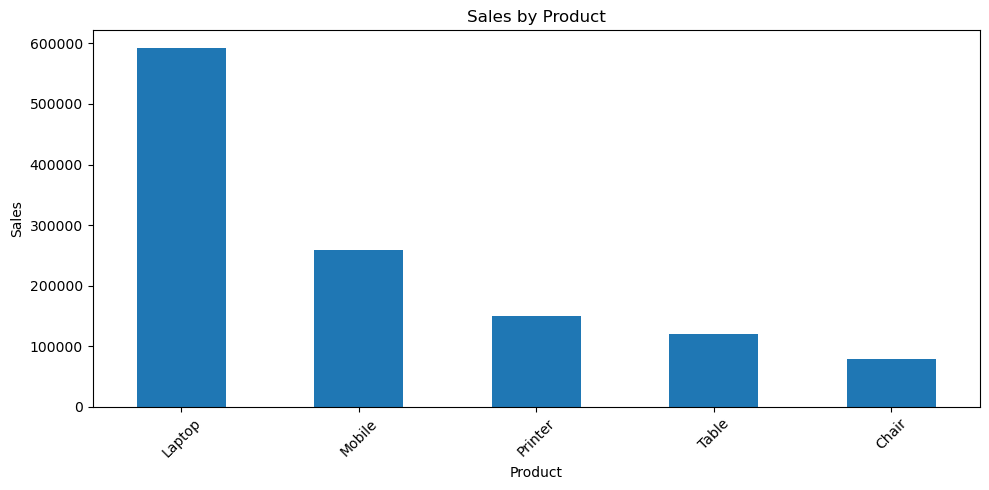

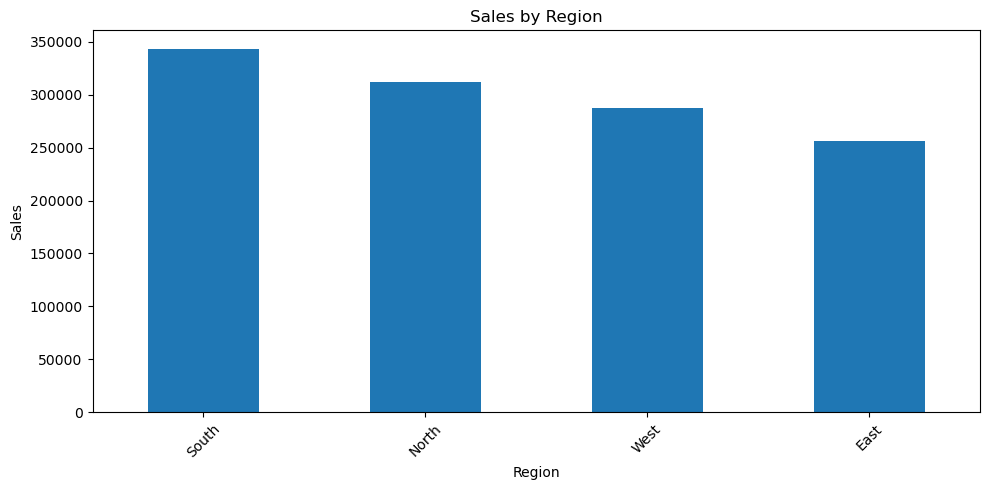

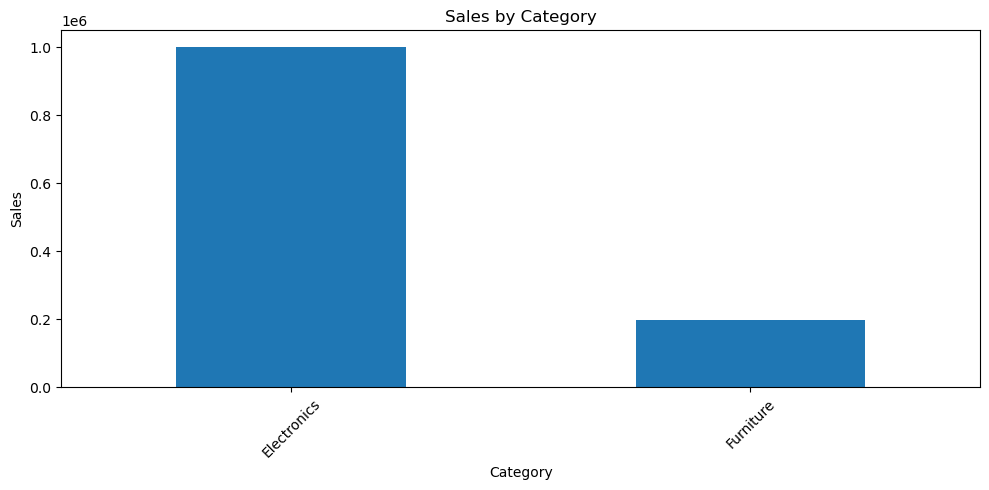

Sales charts created successfully! 📊
          SALES BUSINESS INSIGHTS

PRODUCT INSIGHT
------------------------------------------------------------
Laptop is the top-performing product with sales of ₹592,000.00.

REGION INSIGHT
------------------------------------------------------------
South is the highest-performing region with sales of ₹343,500.00.

CATEGORY INSIGHT
------------------------------------------------------------
Electronics is the strongest category with sales of ₹1,000,200.00.
Furniture is the lowest-performing category with sales of ₹198,900.00.

BUSINESS RECOMMENDATION
------------------------------------------------------------
Focus more marketing and inventory on Laptop because it generates the highest sales.
Review the performance of Furniture and identify opportunities to improve its sales.

Sales business insights completed! ✅


        🎉 MASTER DATA ANALYSIS COMPLETED!


In [61]:
df_sales = analyze_file("14.xlsx")

In [62]:
def save_analysis_summary(df, filename="AI_Data_Analysis_Report.txt"):

    with open(filename, "w", encoding="utf-8") as file:

        file.write("=" * 70 + "\n")
        file.write("           AI DATA ANALYSIS REPORT\n")
        file.write("=" * 70 + "\n\n")

        file.write("DATASET INFORMATION\n")
        file.write("-" * 70 + "\n")

        file.write(f"Rows: {len(df)}\n")
        file.write(f"Columns: {len(df.columns)}\n")
        file.write(f"Duplicate Rows: {df.duplicated().sum()}\n")
        file.write(f"Missing Values: {df.isnull().sum().sum()}\n\n")

        file.write("COLUMN INFORMATION\n")
        file.write("-" * 70 + "\n")

        for col in df.columns:
            file.write(f"- {col}\n")

        file.write("\n")
        file.write("=" * 70 + "\n")
        file.write("           REPORT GENERATED SUCCESSFULLY\n")
        file.write("=" * 70 + "\n")

    print(f"\nReport saved successfully! ✅")
    print(f"File: {filename}")

    return filename

In [63]:
report_file = save_analysis_summary(df_sales)


Report saved successfully! ✅
File: AI_Data_Analysis_Report.txt


In [64]:
with open("AI_Data_Analysis_Report.txt", "r", encoding="utf-8") as file:
    report = file.read()

print(report)

           AI DATA ANALYSIS REPORT

DATASET INFORMATION
----------------------------------------------------------------------
Rows: 51
Columns: 17
Duplicate Rows: 0
Missing Values: 506

COLUMN INFORMATION
----------------------------------------------------------------------
- order_id
- product
- category
- region
- sales
- quantity
- total sales
- average sales
- highest sales
- lowest sales
- electronics category total sales
- furniture category total sales
- north region total sales
- if
- product laptop total entries
- south region average sales
- total quantity

           REPORT GENERATED SUCCESSFULLY



In [65]:
def create_sales_report(df, filename="Professional_Sales_Report.txt"):

    # Sales calculations
    total_sales = df["sales"].sum()
    average_sales = df["sales"].mean()
    highest_sale = df["sales"].max()
    lowest_sale = df["sales"].min()

    total_quantity = df["quantity"].sum()
    total_orders = df["order_id"].nunique()

    # Product
    product_sales = (
        df.groupby("product")["sales"]
        .sum()
        .sort_values(ascending=False)
    )

    top_product = product_sales.index[0]
    top_product_sales = product_sales.iloc[0]

    # Region
    region_sales = (
        df.groupby("region")["sales"]
        .sum()
        .sort_values(ascending=False)
    )

    top_region = region_sales.index[0]
    top_region_sales = region_sales.iloc[0]

    # Category
    category_sales = (
        df.groupby("category")["sales"]
        .sum()
        .sort_values(ascending=False)
    )

    top_category = category_sales.index[0]
    top_category_sales = category_sales.iloc[0]

    lowest_category = category_sales.index[-1]
    lowest_category_sales = category_sales.iloc[-1]

    # Create report
    with open(filename, "w", encoding="utf-8") as file:

        file.write("=" * 70 + "\n")
        file.write("              AI SALES ANALYSIS REPORT\n")
        file.write("=" * 70 + "\n\n")

        file.write("DATA QUALITY\n")
        file.write("-" * 70 + "\n")
        file.write(f"Rows: {len(df)}\n")
        file.write(f"Columns: {len(df.columns)}\n")
        file.write(f"Duplicate Rows: {df.duplicated().sum()}\n")
        file.write(f"Missing Values: {df.isnull().sum().sum()}\n\n")

        file.write("SALES KPIs\n")
        file.write("-" * 70 + "\n")
        file.write(f"Total Sales: ₹{total_sales:,.2f}\n")
        file.write(f"Average Sale: ₹{average_sales:,.2f}\n")
        file.write(f"Highest Sale: ₹{highest_sale:,.2f}\n")
        file.write(f"Lowest Sale: ₹{lowest_sale:,.2f}\n")
        file.write(f"Total Orders: {total_orders}\n")
        file.write(f"Total Quantity Sold: {total_quantity:,.0f}\n\n")

        file.write("TOP PERFORMERS\n")
        file.write("-" * 70 + "\n")
        file.write(
            f"Top Product: {top_product} "
            f"(₹{top_product_sales:,.2f})\n"
        )

        file.write(
            f"Top Region: {top_region} "
            f"(₹{top_region_sales:,.2f})\n"
        )

        file.write(
            f"Top Category: {top_category} "
            f"(₹{top_category_sales:,.2f})\n\n"
        )

        file.write("BUSINESS INSIGHTS\n")
        file.write("-" * 70 + "\n")

        file.write(
            f"{top_product} is the top-performing product "
            f"with sales of ₹{top_product_sales:,.2f}.\n"
        )

        file.write(
            f"{top_region} is the highest-performing region "
            f"with sales of ₹{top_region_sales:,.2f}.\n"
        )

        file.write(
            f"{lowest_category} is the lowest-performing category "
            f"with sales of ₹{lowest_category_sales:,.2f}.\n\n"
        )

        file.write("RECOMMENDATIONS\n")
        file.write("-" * 70 + "\n")

        file.write(
            f"Focus marketing and inventory on {top_product}.\n"
        )

        file.write(
            f"Review {lowest_category} performance "
            f"and identify improvement opportunities.\n"
        )

        file.write("\n" + "=" * 70 + "\n")
        file.write("       REPORT GENERATED BY AI DATA AGENT\n")
        file.write("=" * 70 + "\n")

    print("Professional report created successfully! ✅")
    print(f"File: {filename}")

    return filename

In [66]:
professional_report = create_sales_report(df_sales_clean)

Professional report created successfully! ✅
File: Professional_Sales_Report.txt


In [67]:
from reportlab.lib.pagesizes import A4
from reportlab.platypus import SimpleDocTemplate, Paragraph, Spacer
from reportlab.lib.styles import getSampleStyleSheet

def create_pdf_report(
    txt_file="Professional_Sales_Report.txt",
    pdf_file="Professional_Sales_Report.pdf"
):

    styles = getSampleStyleSheet()

    document = SimpleDocTemplate(
        pdf_file,
        pagesize=A4
    )

    story = []

    with open(txt_file, "r", encoding="utf-8") as file:
        lines = file.readlines()

    for line in lines:

        line = line.strip()

        if not line:
            story.append(Spacer(1, 8))

        elif line.startswith("="):
            story.append(Spacer(1, 5))

        elif line.isupper():
            story.append(
                Paragraph(
                    f"<b>{line}</b>",
                    styles["Heading2"]
                )
            )

        else:
            story.append(
                Paragraph(
                    line,
                    styles["BodyText"]
                )
            )

    document.build(story)

    print("PDF report created successfully! ✅")
    print(f"File: {pdf_file}")

    return pdf_file

ModuleNotFoundError: No module named 'reportlab'

In [69]:
!pip install reportlab

Defaulting to user installation because normal site-packages is not writeable


In [70]:
import sys

print(sys.executable)

C:\ProgramData\anaconda3\python.exe


In [71]:
import sys
!{sys.executable} -m pip install reportlab

Defaulting to user installation because normal site-packages is not writeable


In [72]:
from reportlab.lib.pagesizes import A4

print("ReportLab working successfully! ✅")

ModuleNotFoundError: No module named 'reportlab'

In [73]:
import sys
import subprocess

subprocess.check_call([
    sys.executable,
    "-m",
    "pip",
    "install",
    "--upgrade",
    "--force-reinstall",
    "reportlab"
])

0

In [74]:
import sys
print(sys.executable)

from reportlab.lib.pagesizes import A4

print("ReportLab working successfully! ✅")

C:\ProgramData\anaconda3\python.exe


ModuleNotFoundError: No module named 'reportlab'

In [75]:
import sys

print(sys.executable)

from reportlab.lib.pagesizes import A4

print("ReportLab working successfully! ✅")

C:\ProgramData\anaconda3\python.exe


ModuleNotFoundError: No module named 'reportlab'

In [76]:
%pip install reportlab

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [77]:
import site
import sys

user_site = site.getusersitepackages()

print("User site:")
print(user_site)

if user_site not in sys.path:
    sys.path.append(user_site)

print("\nPython path updated! ✅")

User site:
C:\Users\KAMAL DEWANGAN\AppData\Roaming\Python\Python312\site-packages

Python path updated! ✅


In [78]:
from reportlab.lib.pagesizes import A4
from reportlab.platypus import SimpleDocTemplate, Paragraph, Spacer
from reportlab.lib.styles import getSampleStyleSheet

print("ReportLab working successfully! ✅")

ReportLab working successfully! ✅


In [79]:
pdf_file = create_pdf_report()

NameError: name 'create_pdf_report' is not defined

In [80]:
from reportlab.lib.pagesizes import A4
from reportlab.platypus import SimpleDocTemplate, Paragraph, Spacer
from reportlab.lib.styles import getSampleStyleSheet


def create_pdf_report(
    txt_file="Professional_Sales_Report.txt",
    pdf_file="Professional_Sales_Report.pdf"
):

    styles = getSampleStyleSheet()

    document = SimpleDocTemplate(
        pdf_file,
        pagesize=A4
    )

    story = []

    with open(txt_file, "r", encoding="utf-8") as file:
        lines = file.readlines()

    for line in lines:

        line = line.strip()

        if not line:
            story.append(Spacer(1, 8))

        elif line.startswith("="):
            story.append(Spacer(1, 5))

        elif line.isupper():
            story.append(
                Paragraph(
                    f"<b>{line}</b>",
                    styles["Heading2"]
                )
            )

        else:
            story.append(
                Paragraph(
                    line,
                    styles["BodyText"]
                )
            )

    document.build(story)

    print("PDF report created successfully! ✅")
    print(f"File: {pdf_file}")

    return pdf_file

In [81]:
pdf_file = create_pdf_report()

PDF report created successfully! ✅
File: Professional_Sales_Report.pdf


In [82]:
import os

print(os.path.exists("Professional_Sales_Report.pdf"))

True


In [83]:
import matplotlib.pyplot as plt


def save_sales_charts(df):

    # Product Chart
    product_sales = (
        df.groupby("product")["sales"]
        .sum()
        .sort_values(ascending=False)
    )

    plt.figure(figsize=(10, 5))
    product_sales.plot(kind="bar")
    plt.title("Sales by Product")
    plt.xlabel("Product")
    plt.ylabel("Sales")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig("sales_by_product.png")
    plt.close()


    # Region Chart
    region_sales = (
        df.groupby("region")["sales"]
        .sum()
        .sort_values(ascending=False)
    )

    plt.figure(figsize=(10, 5))
    region_sales.plot(kind="bar")
    plt.title("Sales by Region")
    plt.xlabel("Region")
    plt.ylabel("Sales")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig("sales_by_region.png")
    plt.close()


    # Category Chart
    category_sales = (
        df.groupby("category")["sales"]
        .sum()
        .sort_values(ascending=False)
    )

    plt.figure(figsize=(10, 5))
    category_sales.plot(kind="bar")
    plt.title("Sales by Category")
    plt.xlabel("Category")
    plt.ylabel("Sales")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig("sales_by_category.png")
    plt.close()


    print("Sales chart images saved successfully! ✅")

In [84]:
save_sales_charts(df_sales_clean)

Sales chart images saved successfully! ✅


In [85]:
from reportlab.lib.pagesizes import A4
from reportlab.platypus import (
    SimpleDocTemplate,
    Paragraph,
    Spacer,
    Image,
    PageBreak
)
from reportlab.lib.styles import getSampleStyleSheet


def create_final_sales_pdf(
    txt_file="Professional_Sales_Report.txt",
    pdf_file="Final_AI_Sales_Report.pdf"
):

    styles = getSampleStyleSheet()

    document = SimpleDocTemplate(
        pdf_file,
        pagesize=A4
    )

    story = []

    # -----------------------------
    # Report Text
    # -----------------------------

    with open(txt_file, "r", encoding="utf-8") as file:
        lines = file.readlines()

    for line in lines:

        line = line.strip()

        if not line:
            story.append(Spacer(1, 8))

        elif line.startswith("="):
            story.append(Spacer(1, 5))

        elif line.isupper():
            story.append(
                Paragraph(
                    f"<b>{line}</b>",
                    styles["Heading2"]
                )
            )

        else:
            story.append(
                Paragraph(
                    line,
                    styles["BodyText"]
                )
            )

    # -----------------------------
    # Charts
    # -----------------------------

    story.append(PageBreak())

    story.append(
        Paragraph(
            "<b>SALES VISUAL ANALYSIS</b>",
            styles["Heading1"]
        )
    )

    story.append(Spacer(1, 15))

    # Product Chart
    story.append(
        Paragraph(
            "<b>Sales by Product</b>",
            styles["Heading2"]
        )
    )

    story.append(
        Image(
            "sales_by_product.png",
            width=500,
            height=250
        )
    )

    story.append(PageBreak())

    # Region Chart
    story.append(
        Paragraph(
            "<b>Sales by Region</b>",
            styles["Heading2"]
        )
    )

    story.append(
        Image(
            "sales_by_region.png",
            width=500,
            height=250
        )
    )

    story.append(PageBreak())

    # Category Chart
    story.append(
        Paragraph(
            "<b>Sales by Category</b>",
            styles["Heading2"]
        )
    )

    story.append(
        Image(
            "sales_by_category.png",
            width=500,
            height=250
        )
    )

    document.build(story)

    print("==============================================")
    print("FINAL AI SALES PDF CREATED! ✅")
    print("==============================================")
    print(f"File: {pdf_file}")

    return pdf_file

In [86]:
final_pdf = create_final_sales_pdf()

FINAL AI SALES PDF CREATED! ✅
File: Final_AI_Sales_Report.pdf


In [87]:
import os

print("PDF exists:", os.path.exists("Final_AI_Sales_Report.pdf"))

if os.path.exists("Final_AI_Sales_Report.pdf"):
    print("PDF size:", os.path.getsize("Final_AI_Sales_Report.pdf"), "bytes")

PDF exists: True
PDF size: 90645 bytes




             🚀 AUTOMATIC DATA ANALYZER
Dataset loaded successfully! ✅
Rows: 51
Columns: 78

Dataset loaded. Starting analysis...



              🤖 MASTER AI DATA AGENT
Column names cleaned successfully! ✅
Clean columns:
['order_id', 'product', 'category', 'region', 'sales', 'quantity', 'unnamed: 6', 'total sales', 'average sales', 'highest sales', 'lowest sales', 'electronics category total sales', 'furniture category total sales', 'north region total sales', 'if', 'product laptop total entries', 'south region average sales', 'total quantity', 'unnamed: 18', 'unnamed: 19', 'unnamed: 20', 'unnamed: 21', 'unnamed: 22', 'unnamed: 23', 'unnamed: 24', 'unnamed: 25', 'unnamed: 26', 'unnamed: 27', 'unnamed: 28', 'unnamed: 29', 'unnamed: 30', 'unnamed: 31', 'unnamed: 32', 'unnamed: 33', 'unnamed: 34', 'unnamed: 35', 'unnamed: 36', 'unnamed: 37', 'unnamed: 38', 'unnamed: 39', 'unnamed: 40', 'unnamed: 41', 'unnamed: 42', 'unnamed: 43', 'unnamed: 44', 'unnamed: 45', 'unnamed: 46', 'unnamed: 47

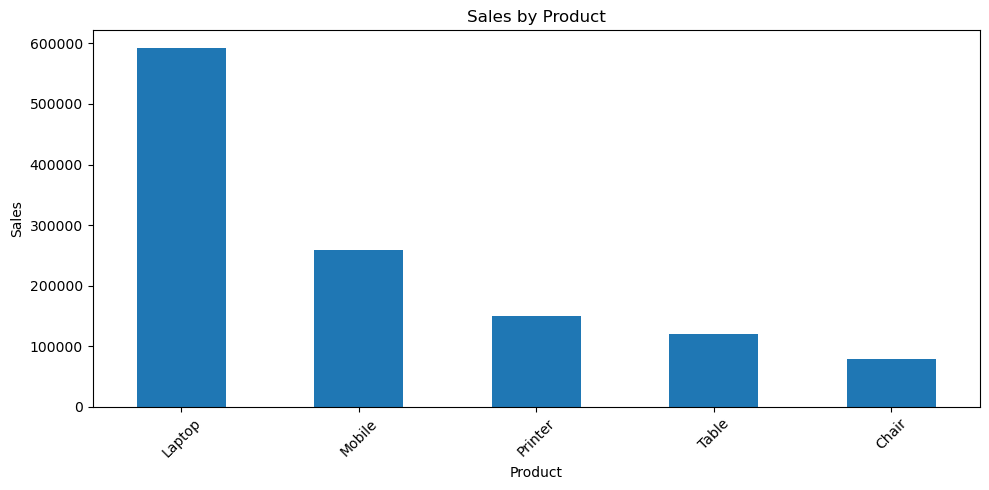

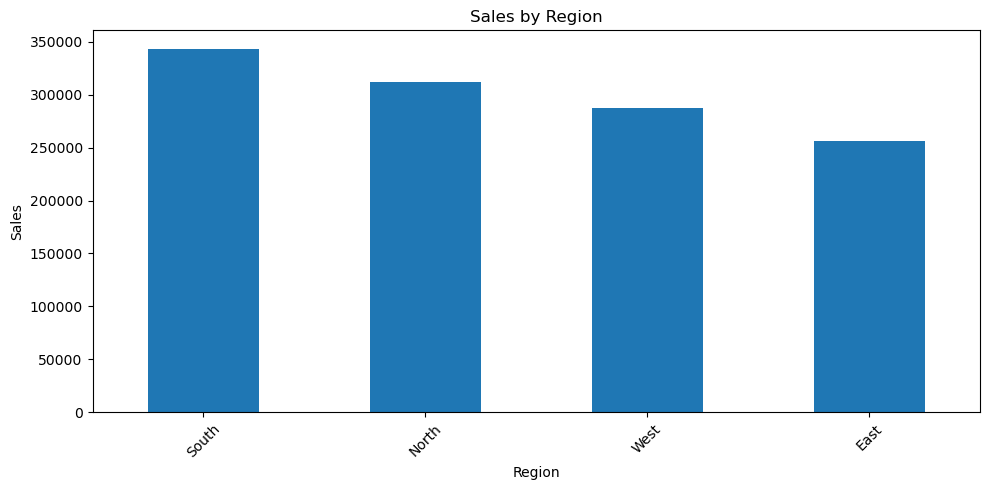

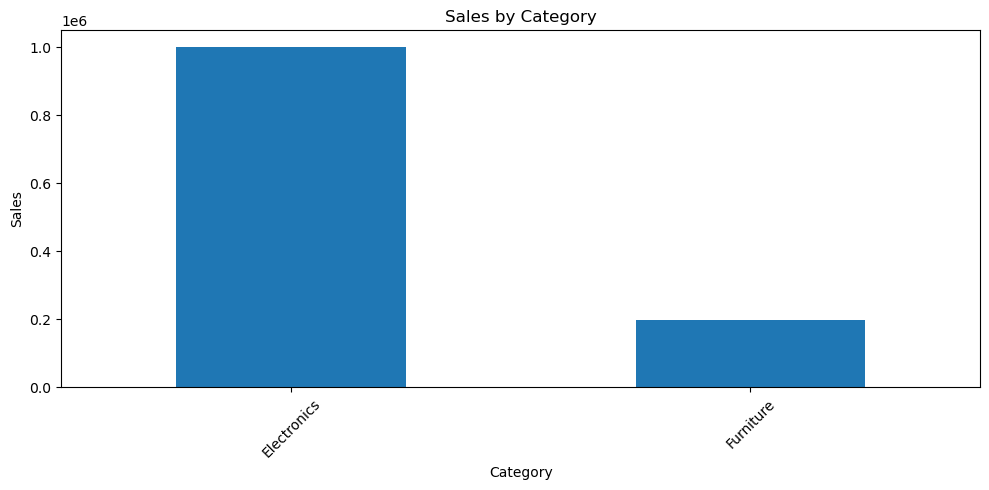

Sales charts created successfully! 📊
          SALES BUSINESS INSIGHTS

PRODUCT INSIGHT
------------------------------------------------------------
Laptop is the top-performing product with sales of ₹592,000.00.

REGION INSIGHT
------------------------------------------------------------
South is the highest-performing region with sales of ₹343,500.00.

CATEGORY INSIGHT
------------------------------------------------------------
Electronics is the strongest category with sales of ₹1,000,200.00.
Furniture is the lowest-performing category with sales of ₹198,900.00.

BUSINESS RECOMMENDATION
------------------------------------------------------------
Focus more marketing and inventory on Laptop because it generates the highest sales.
Review the performance of Furniture and identify opportunities to improve its sales.

Sales business insights completed! ✅


        🎉 MASTER DATA ANALYSIS COMPLETED!


,order_id,product,category,region,sales,quantity,total sales,average sales,highest sales,lowest sales,electronics category total sales,furniture category total sales,north region total sales,if,product laptop total entries,south region average sales,total quantity
0,1001,Laptop,Electronics,North,55000.0,2.0,1199100.0,23982.0,63000.0,7000.0,1000200.0,198900.0,311800.0,High,10.0,26423.076923,121.0
1,1002,Mobile,Electronics,South,25000.0,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Low,NaN,NaN,NaN
2,1003,Chair,Furniture,East,7000.0,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Low,NaN,NaN,NaN
3,1004,Table,Furniture,West,12000.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Low,NaN,NaN,NaN
4,1005,Printer,Electronics,North,15000.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Low,NaN,NaN,NaN
5,1006,Laptop,Electronics,South,60000.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,High,NaN,NaN,NaN
6,1007,Chair,Furniture,East,8000.0,5.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Low,NaN,NaN,NaN
7,1008,Mobile,Electronics,West,27000.0,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,High,NaN,NaN,NaN
8,1009,Table,Furniture,North,11000.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Low,NaN,NaN,NaN
9,1010,Printer,Electronics,South,14000.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Low,NaN,NaN,NaN


In [88]:
analyze_file("14.xlsx")

In [89]:
def one_click_sales_agent(file_path):

    print("=" * 70)
    print("          🤖 ONE-CLICK AI SALES AGENT")
    print("=" * 70)

    # 1. Load file
    print("\n[1/7] Loading dataset...")
    df = load_file(file_path)

    # 2. Clean columns
    print("\n[2/7] Cleaning columns...")
    df = clean_columns(df)

    # 3. Detect dataset
    print("\n[3/7] Detecting dataset...")
    dataset_type = detect_dataset_type(df)

    print(f"Detected: {dataset_type}")

    # 4. Sales analysis
    if dataset_type == "Sales Dataset":

        print("\n[4/7] Cleaning sales data...")
        df = clean_sales_data(df)

        print("\n[5/7] Generating KPIs...")
        smart_sales_kpis(df)

        print("\n[6/7] Creating charts...")
        save_sales_charts(df)

        print("\n[7/7] Generating insights...")
        sales_business_insights(df)

        # Reports
        create_sales_report(df)

        create_final_sales_pdf()

        print("\n" + "=" * 70)
        print("       🎉 ONE-CLICK SALES ANALYSIS COMPLETED!")
        print("=" * 70)

        print("\nGenerated files:")
        print("• Professional_Sales_Report.txt")
        print("• Final_AI_Sales_Report.pdf")
        print("• sales_by_product.png")
        print("• sales_by_region.png")
        print("• sales_by_category.png")

        return df

    else:

        print("\nThis version currently supports Sales Dataset.")
        print("Employee automation will be added next.")

        return df

In [90]:
one_click_sales_agent("14.xlsx")

          🤖 ONE-CLICK AI SALES AGENT

[1/7] Loading dataset...


NameError: name 'load_file' is not defined

In [91]:
import pandas as pd
import os


def load_file(file_path):

    if not os.path.exists(file_path):
        raise FileNotFoundError(
            f"File not found: {file_path}"
        )

    extension = os.path.splitext(file_path)[1].lower()

    if extension == ".csv":
        df = pd.read_csv(file_path)

    elif extension in [".xlsx", ".xls"]:
        df = pd.read_excel(file_path)

    else:
        raise ValueError(
            "Only CSV and Excel files are supported."
        )

    print("File loaded successfully! ✅")
    print(f"Rows: {len(df)}")
    print(f"Columns: {len(df.columns)}")

    return df

In [92]:
test_df = load_file("14.xlsx")

File loaded successfully! ✅
Rows: 51
Columns: 78


In [93]:
one_click_sales_agent("14.xlsx")

          🤖 ONE-CLICK AI SALES AGENT

[1/7] Loading dataset...
File loaded successfully! ✅
Rows: 51
Columns: 78

[2/7] Cleaning columns...
Column names cleaned successfully! ✅
Clean columns:
['order_id', 'product', 'category', 'region', 'sales', 'quantity', 'unnamed: 6', 'total sales', 'average sales', 'highest sales', 'lowest sales', 'electronics category total sales', 'furniture category total sales', 'north region total sales', 'if', 'product laptop total entries', 'south region average sales', 'total quantity', 'unnamed: 18', 'unnamed: 19', 'unnamed: 20', 'unnamed: 21', 'unnamed: 22', 'unnamed: 23', 'unnamed: 24', 'unnamed: 25', 'unnamed: 26', 'unnamed: 27', 'unnamed: 28', 'unnamed: 29', 'unnamed: 30', 'unnamed: 31', 'unnamed: 32', 'unnamed: 33', 'unnamed: 34', 'unnamed: 35', 'unnamed: 36', 'unnamed: 37', 'unnamed: 38', 'unnamed: 39', 'unnamed: 40', 'unnamed: 41', 'unnamed: 42', 'unnamed: 43', 'unnamed: 44', 'unnamed: 45', 'unnamed: 46', 'unnamed: 47', 'unnamed: 48', 'unnamed: 49',

,order_id,product,category,region,sales,quantity,total sales,average sales,highest sales,lowest sales,electronics category total sales,furniture category total sales,north region total sales,if,product laptop total entries,south region average sales,total quantity
0,1001,Laptop,Electronics,North,55000.0,2.0,1199100.0,23982.0,63000.0,7000.0,1000200.0,198900.0,311800.0,High,10.0,26423.076923,121.0
1,1002,Mobile,Electronics,South,25000.0,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Low,NaN,NaN,NaN
2,1003,Chair,Furniture,East,7000.0,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Low,NaN,NaN,NaN
3,1004,Table,Furniture,West,12000.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Low,NaN,NaN,NaN
4,1005,Printer,Electronics,North,15000.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Low,NaN,NaN,NaN
5,1006,Laptop,Electronics,South,60000.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,High,NaN,NaN,NaN
6,1007,Chair,Furniture,East,8000.0,5.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Low,NaN,NaN,NaN
7,1008,Mobile,Electronics,West,27000.0,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,High,NaN,NaN,NaN
8,1009,Table,Furniture,North,11000.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Low,NaN,NaN,NaN
9,1010,Printer,Electronics,South,14000.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Low,NaN,NaN,NaN


In [94]:
import os

files = [
    "Professional_Sales_Report.txt",
    "Final_AI_Sales_Report.pdf",
    "sales_by_product.png",
    "sales_by_region.png",
    "sales_by_category.png"
]

for file in files:
    print(file, "→", "✅ Created" if os.path.exists(file) else "❌ Missing")

Professional_Sales_Report.txt → ✅ Created
Final_AI_Sales_Report.pdf → ✅ Created
sales_by_product.png → ✅ Created
sales_by_region.png → ✅ Created
sales_by_category.png → ✅ Created


In [95]:
def universal_data_agent(file_path):

    print("=" * 70)
    print("        🤖 UNIVERSAL AI DATA ANALYSIS AGENT")
    print("=" * 70)

    # 1. Load
    print("\n[1/6] Loading dataset...")
    df = load_file(file_path)

    # 2. Clean columns
    print("\n[2/6] Cleaning columns...")
    df = clean_columns(df)

    # 3. Detect dataset
    print("\n[3/6] Detecting dataset...")
    dataset_type = detect_dataset_type(df)

    print(f"\nDetected Dataset: {dataset_type}")

    # 4. Sales
    if dataset_type == "Sales Dataset":

        print("\n[4/6] Running Sales Analysis...")
        df = clean_sales_data(df)

        smart_sales_kpis(df)

        print("\n[5/6] Generating Sales Insights...")
        sales_business_insights(df)

        print("\n[6/6] Creating Sales Charts & Report...")
        save_sales_charts(df)
        create_sales_report(df)
        create_final_sales_pdf()

        print("\n" + "=" * 70)
        print("       🎉 SALES ANALYSIS COMPLETED!")
        print("=" * 70)

    # 5. Employee
    elif dataset_type == "Employee Dataset":

        print("\n[4/6] Running Employee Analysis...")

        automatic_kpis(df)
        automatic_insights(df)

        print("\n[5/6] Creating Employee Charts...")
        create_employee_charts(df)

        print("\n[6/6] Creating Employee Report...")
        create_employee_report(df)

        print("\n" + "=" * 70)
        print("       🎉 EMPLOYEE ANALYSIS COMPLETED!")
        print("=" * 70)

    # 6. Unknown
    else:

        print("\n[4/6] Running General Analysis...")

        automatic_kpis(df)
        automatic_insights(df)

        print("\n[5/6] Basic analysis completed.")

        print("\n[6/6] Dataset requires specialized analysis.")

    return df

In [96]:
result_df = universal_data_agent("14.xlsx")

        🤖 UNIVERSAL AI DATA ANALYSIS AGENT

[1/6] Loading dataset...
File loaded successfully! ✅
Rows: 51
Columns: 78

[2/6] Cleaning columns...
Column names cleaned successfully! ✅
Clean columns:
['order_id', 'product', 'category', 'region', 'sales', 'quantity', 'unnamed: 6', 'total sales', 'average sales', 'highest sales', 'lowest sales', 'electronics category total sales', 'furniture category total sales', 'north region total sales', 'if', 'product laptop total entries', 'south region average sales', 'total quantity', 'unnamed: 18', 'unnamed: 19', 'unnamed: 20', 'unnamed: 21', 'unnamed: 22', 'unnamed: 23', 'unnamed: 24', 'unnamed: 25', 'unnamed: 26', 'unnamed: 27', 'unnamed: 28', 'unnamed: 29', 'unnamed: 30', 'unnamed: 31', 'unnamed: 32', 'unnamed: 33', 'unnamed: 34', 'unnamed: 35', 'unnamed: 36', 'unnamed: 37', 'unnamed: 38', 'unnamed: 39', 'unnamed: 40', 'unnamed: 41', 'unnamed: 42', 'unnamed: 43', 'unnamed: 44', 'unnamed: 45', 'unnamed: 46', 'unnamed: 47', 'unnamed: 48', 'unnamed

In [97]:
employee_test = pd.DataFrame({
    "name": [
        "shradha",
        "vandana",
        "bhawani",
        "diviya",
        "radhav",
        "bharti",
        "harsh",
        "niya"
    ],
    "department": [
        "sales",
        "fainancial",
        "hr",
        "face cear",
        "skincare",
        "bodycare",
        "hr",
        "sales"
    ],
    "salary": [
        6000,
        9000,
        12000,
        450000,
        4500,
        27634,
        90000,
        2345678
    ]
})

print(employee_test)

      name  department   salary
0  shradha       sales     6000
1  vandana  fainancial     9000
2  bhawani          hr    12000
3   diviya   face cear   450000
4   radhav    skincare     4500
5   bharti    bodycare    27634
6    harsh          hr    90000
7     niya       sales  2345678


        🤖 UNIVERSAL AI DATA ANALYSIS AGENT

[1/6] Loading dataset...
File loaded successfully! ✅
Rows: 8
Columns: 3

[2/6] Cleaning columns...
Column names cleaned successfully! ✅
Clean columns:
['name', 'department', 'salary']

[3/6] Detecting dataset...
        DATASET TYPE DETECTION
Detected Dataset: Employee Dataset

Detected Dataset: Employee Dataset

[4/6] Running Employee Analysis...
             AUTOMATIC KPI REPORT

COLUMN: salary
------------------------------------------------------------
Total: 2,944,812.00
Average: 368,101.50
Highest: 2,345,678.00
Lowest: 4,500.00

Automatic KPI generation completed! ✅
          AUTOMATIC BUSINESS INSIGHTS

INSIGHT FOR: salary
------------------------------------------------------------
Average salary: 368,101.50
Highest salary: 2,345,678.00
Lowest salary: 4,500.00

CATEGORY INSIGHT: name
------------------------------------------------------------
Most common name: bharti (1 records).

CATEGORY INSIGHT: department
------------------------

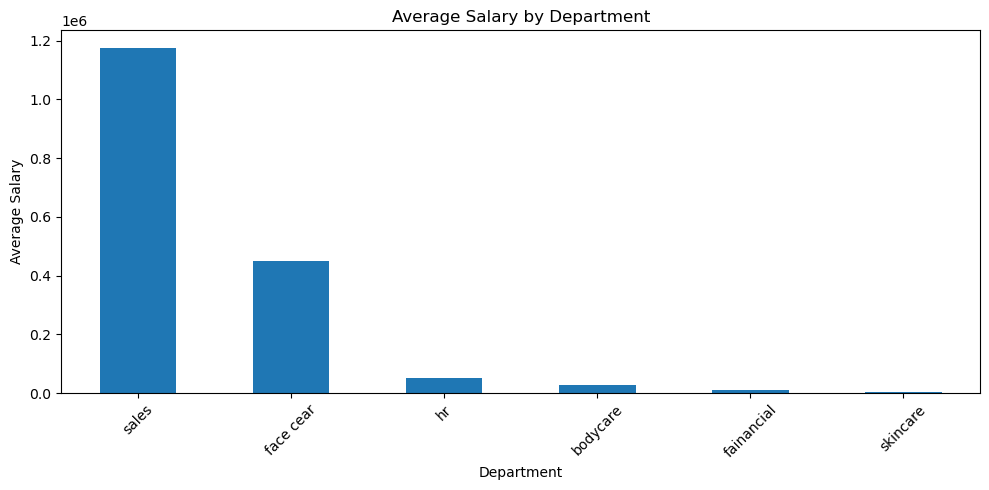

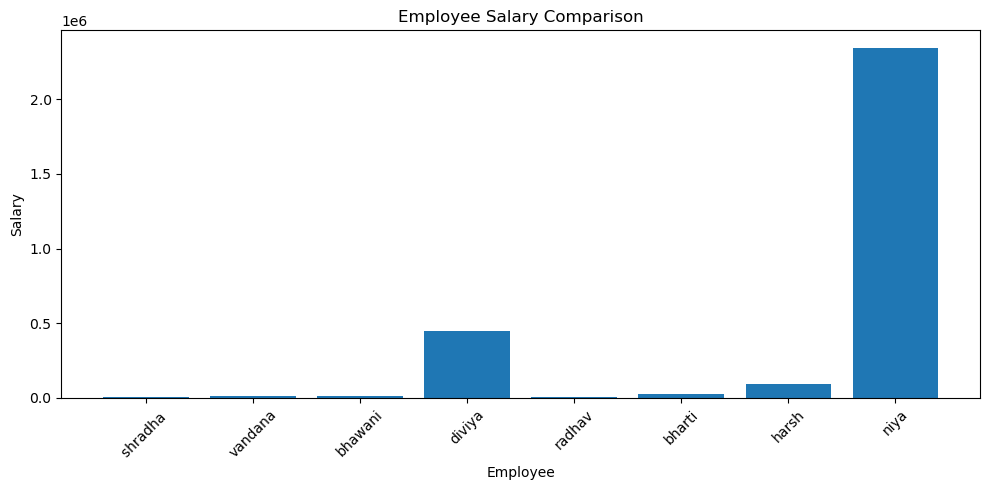

Employee charts created successfully! 📊

[6/6] Creating Employee Report...
       PROFESSIONAL EMPLOYEE ANALYSIS REPORT

DATA QUALITY
------------------------------------------------------------
Rows: 8
Columns: 3
Duplicate rows: 0
Missing values: 0

SALARY KPIs
------------------------------------------------------------
Total Salary: ₹2,944,812.00
Average Salary: ₹368,101.50
Highest Salary: ₹2,345,678.00
Lowest Salary: ₹4,500.00

TOP EMPLOYEE
------------------------------------------------------------
Highest-paid employee: niya

DEPARTMENT ANALYSIS
------------------------------------------------------------
Highest average salary department: sales
Average salary: ₹1,175,839.00

BUSINESS INSIGHTS
------------------------------------------------------------
sales has the highest average salary at ₹1,175,839.00.
niya has the highest salary in the dataset.

       Report completed successfully!

       🎉 EMPLOYEE ANALYSIS COMPLETED!


In [98]:
universal_employee_result = universal_data_agent("csv.csv")

In [99]:
print("Employee dataset test:")
print("=" * 60)

print("Rows:", len(employee_test))
print("Columns:", list(employee_test.columns))

print("\nDetected type:")
print(detect_dataset_type(employee_test))

Employee dataset test:
Rows: 8
Columns: ['name', 'department', 'salary']

Detected type:
        DATASET TYPE DETECTION
Detected Dataset: Employee Dataset
Employee Dataset


In [100]:
universal_data_agent("14.xlsx")

        🤖 UNIVERSAL AI DATA ANALYSIS AGENT

[1/6] Loading dataset...
File loaded successfully! ✅
Rows: 51
Columns: 78

[2/6] Cleaning columns...
Column names cleaned successfully! ✅
Clean columns:
['order_id', 'product', 'category', 'region', 'sales', 'quantity', 'unnamed: 6', 'total sales', 'average sales', 'highest sales', 'lowest sales', 'electronics category total sales', 'furniture category total sales', 'north region total sales', 'if', 'product laptop total entries', 'south region average sales', 'total quantity', 'unnamed: 18', 'unnamed: 19', 'unnamed: 20', 'unnamed: 21', 'unnamed: 22', 'unnamed: 23', 'unnamed: 24', 'unnamed: 25', 'unnamed: 26', 'unnamed: 27', 'unnamed: 28', 'unnamed: 29', 'unnamed: 30', 'unnamed: 31', 'unnamed: 32', 'unnamed: 33', 'unnamed: 34', 'unnamed: 35', 'unnamed: 36', 'unnamed: 37', 'unnamed: 38', 'unnamed: 39', 'unnamed: 40', 'unnamed: 41', 'unnamed: 42', 'unnamed: 43', 'unnamed: 44', 'unnamed: 45', 'unnamed: 46', 'unnamed: 47', 'unnamed: 48', 'unnamed

,order_id,product,category,region,sales,quantity,total sales,average sales,highest sales,lowest sales,electronics category total sales,furniture category total sales,north region total sales,if,product laptop total entries,south region average sales,total quantity
0,1001,Laptop,Electronics,North,55000.0,2.0,1199100.0,23982.0,63000.0,7000.0,1000200.0,198900.0,311800.0,High,10.0,26423.076923,121.0
1,1002,Mobile,Electronics,South,25000.0,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Low,NaN,NaN,NaN
2,1003,Chair,Furniture,East,7000.0,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Low,NaN,NaN,NaN
3,1004,Table,Furniture,West,12000.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Low,NaN,NaN,NaN
4,1005,Printer,Electronics,North,15000.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Low,NaN,NaN,NaN
5,1006,Laptop,Electronics,South,60000.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,High,NaN,NaN,NaN
6,1007,Chair,Furniture,East,8000.0,5.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Low,NaN,NaN,NaN
7,1008,Mobile,Electronics,West,27000.0,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,High,NaN,NaN,NaN
8,1009,Table,Furniture,North,11000.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Low,NaN,NaN,NaN
9,1010,Printer,Electronics,South,14000.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Low,NaN,NaN,NaN


In [101]:
def universal_agent(data):

    print("=" * 70)
    print("        🤖 UNIVERSAL AI DATA ANALYSIS AGENT")
    print("=" * 70)

    # --------------------------------
    # 1. Load Data
    # --------------------------------

    print("\n[1/6] Loading dataset...")

    if isinstance(data, pd.DataFrame):
        df = data.copy()
        print("DataFrame loaded successfully! ✅")

    else:
        df = load_file(data)
        print("File loaded successfully! ✅")

    # --------------------------------
    # 2. Clean Columns
    # --------------------------------

    print("\n[2/6] Cleaning columns...")

    df = clean_columns(df)

    # --------------------------------
    # 3. Detect Dataset
    # --------------------------------

    print("\n[3/6] Detecting dataset...")

    dataset_type = detect_dataset_type(df)

    print(f"Detected Dataset: {dataset_type}")

    # --------------------------------
    # 4. Sales Analysis
    # --------------------------------

    if dataset_type == "Sales Dataset":

        print("\n[4/6] Running Sales Analysis...")

        df = clean_sales_data(df)

        smart_sales_kpis(df)

        print("\n[5/6] Generating Sales Insights...")

        sales_business_insights(df)

        print("\n[6/6] Creating Charts & Reports...")

        save_sales_charts(df)

        create_sales_report(df)

        create_final_sales_pdf()

        print("\n🎉 SALES ANALYSIS COMPLETED!")

    # --------------------------------
    # 5. Employee Analysis
    # --------------------------------

    elif dataset_type == "Employee Dataset":

        print("\n[4/6] Running Employee Analysis...")

        automatic_kpis(df)

        print("\n[5/6] Generating Employee Insights...")

        automatic_insights(df)

        print("\n[6/6] Creating Employee Charts & Report...")

        create_employee_charts(df)

        create_employee_report(df)

        print("\n🎉 EMPLOYEE ANALYSIS COMPLETED!")

    # --------------------------------
    # 6. Unknown Dataset
    # --------------------------------

    else:

        print("\n[4/6] Running General Analysis...")

        automatic_kpis(df)

        print("\n[5/6] Generating General Insights...")

        automatic_insights(df)

        print("\n[6/6] Basic analysis completed.")

        print("\n⚠️ Specialized analysis not available.")

    return df

        🤖 UNIVERSAL AI DATA ANALYSIS AGENT

[1/6] Loading dataset...
DataFrame loaded successfully! ✅

[2/6] Cleaning columns...
Column names cleaned successfully! ✅
Clean columns:
['name', 'department', 'salary']

[3/6] Detecting dataset...
        DATASET TYPE DETECTION
Detected Dataset: Employee Dataset
Detected Dataset: Employee Dataset

[4/6] Running Employee Analysis...
             AUTOMATIC KPI REPORT

COLUMN: salary
------------------------------------------------------------
Total: 2,944,812.00
Average: 368,101.50
Highest: 2,345,678.00
Lowest: 4,500.00

Automatic KPI generation completed! ✅

[5/6] Generating Employee Insights...
          AUTOMATIC BUSINESS INSIGHTS

INSIGHT FOR: salary
------------------------------------------------------------
Average salary: 368,101.50
Highest salary: 2,345,678.00
Lowest salary: 4,500.00

CATEGORY INSIGHT: name
------------------------------------------------------------
Most common name: bharti (1 records).

CATEGORY INSIGHT: department


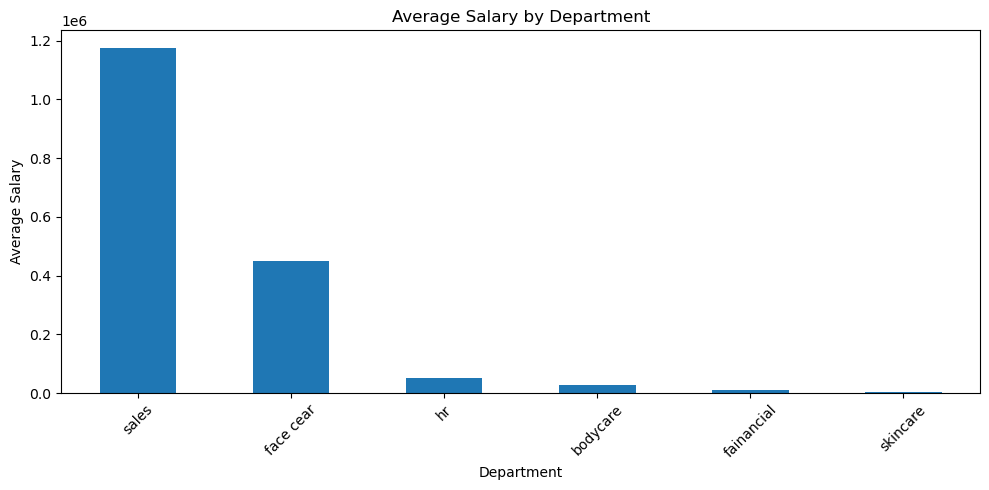

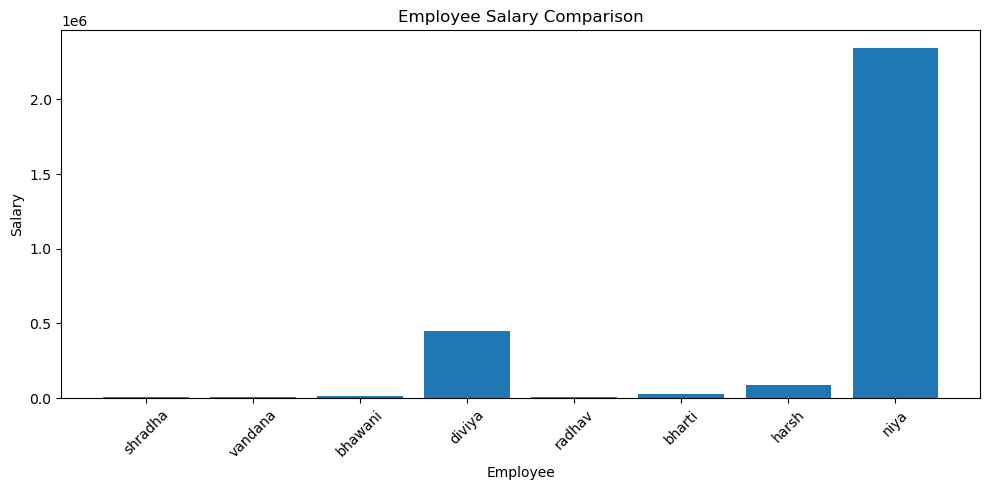

Employee charts created successfully! 📊
       PROFESSIONAL EMPLOYEE ANALYSIS REPORT

DATA QUALITY
------------------------------------------------------------
Rows: 8
Columns: 3
Duplicate rows: 0
Missing values: 0

SALARY KPIs
------------------------------------------------------------
Total Salary: ₹2,944,812.00
Average Salary: ₹368,101.50
Highest Salary: ₹2,345,678.00
Lowest Salary: ₹4,500.00

TOP EMPLOYEE
------------------------------------------------------------
Highest-paid employee: niya

DEPARTMENT ANALYSIS
------------------------------------------------------------
Highest average salary department: sales
Average salary: ₹1,175,839.00

BUSINESS INSIGHTS
------------------------------------------------------------
sales has the highest average salary at ₹1,175,839.00.
niya has the highest salary in the dataset.

       Report completed successfully!

🎉 EMPLOYEE ANALYSIS COMPLETED!


In [102]:
employee_result = universal_agent(employee_test)

        🤖 UNIVERSAL AI DATA ANALYSIS AGENT

[1/6] Loading dataset...
DataFrame loaded successfully! ✅

[2/6] Cleaning columns...
Column names cleaned successfully! ✅
Clean columns:
['name', 'department', 'salary']

[3/6] Detecting dataset...
        DATASET TYPE DETECTION
Detected Dataset: Employee Dataset
Detected Dataset: Employee Dataset

[4/6] Running Employee Analysis...
             AUTOMATIC KPI REPORT

COLUMN: salary
------------------------------------------------------------
Total: 2,944,812.00
Average: 368,101.50
Highest: 2,345,678.00
Lowest: 4,500.00

Automatic KPI generation completed! ✅

[5/6] Generating Employee Insights...
          AUTOMATIC BUSINESS INSIGHTS

INSIGHT FOR: salary
------------------------------------------------------------
Average salary: 368,101.50
Highest salary: 2,345,678.00
Lowest salary: 4,500.00

CATEGORY INSIGHT: name
------------------------------------------------------------
Most common name: bharti (1 records).

CATEGORY INSIGHT: department


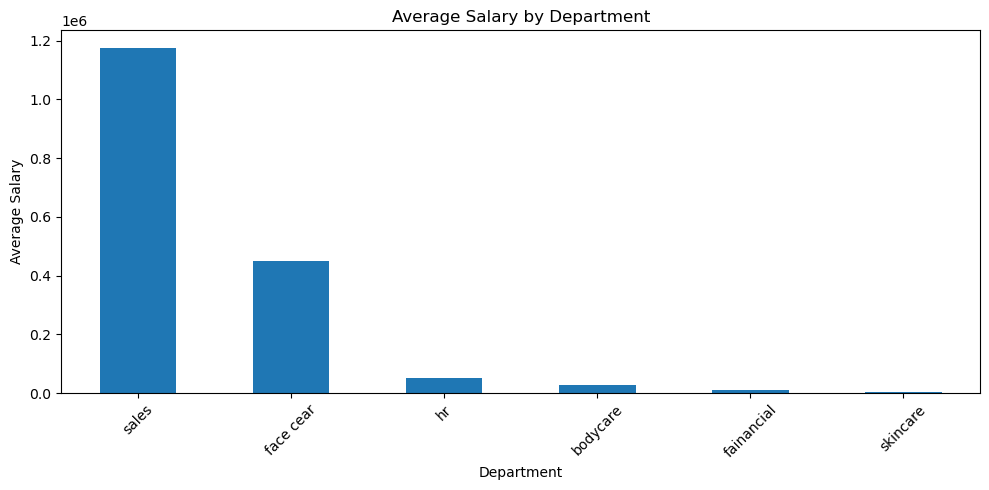

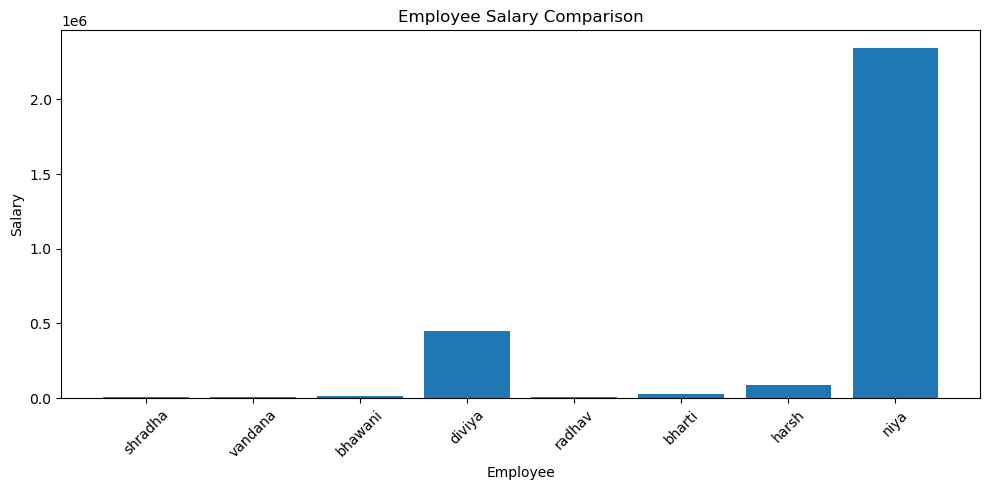

Employee charts created successfully! 📊
       PROFESSIONAL EMPLOYEE ANALYSIS REPORT

DATA QUALITY
------------------------------------------------------------
Rows: 8
Columns: 3
Duplicate rows: 0
Missing values: 0

SALARY KPIs
------------------------------------------------------------
Total Salary: ₹2,944,812.00
Average Salary: ₹368,101.50
Highest Salary: ₹2,345,678.00
Lowest Salary: ₹4,500.00

TOP EMPLOYEE
------------------------------------------------------------
Highest-paid employee: niya

DEPARTMENT ANALYSIS
------------------------------------------------------------
Highest average salary department: sales
Average salary: ₹1,175,839.00

BUSINESS INSIGHTS
------------------------------------------------------------
sales has the highest average salary at ₹1,175,839.00.
niya has the highest salary in the dataset.

       Report completed successfully!

🎉 EMPLOYEE ANALYSIS COMPLETED!


In [103]:
employee_result = universal_agent(employee_test)

In [104]:
def general_dataset_analysis(df):

    print("=" * 70)
    print("          🤖 GENERAL DATASET ANALYSIS")
    print("=" * 70)

    print("\nDATASET OVERVIEW")
    print("-" * 70)

    print(f"Rows: {len(df)}")
    print(f"Columns: {len(df.columns)}")
    print(f"Duplicate Rows: {df.duplicated().sum()}")
    print(f"Missing Values: {df.isnull().sum().sum()}")

    # Numeric columns
    numeric_columns = df.select_dtypes(
        include="number"
    ).columns.tolist()

    print("\nNUMERIC COLUMNS")
    print("-" * 70)

    if numeric_columns:

        for col in numeric_columns:
            print(f"• {col}")

    else:
        print("No numeric columns found.")

    # Categorical columns
    categorical_columns = df.select_dtypes(
        exclude="number"
    ).columns.tolist()

    print("\nCATEGORICAL COLUMNS")
    print("-" * 70)

    if categorical_columns:

        for col in categorical_columns:
            print(f"• {col}")

    else:
        print("No categorical columns found.")

    # Numeric KPIs
    print("\nNUMERIC KPI SUMMARY")
    print("-" * 70)

    for col in numeric_columns:

        series = pd.to_numeric(
            df[col],
            errors="coerce"
        ).dropna()

        if len(series) == 0:
            continue

        print(f"\nCOLUMN: {col}")

        print(f"Total: {series.sum():,.2f}")
        print(f"Average: {series.mean():,.2f}")
        print(f"Highest: {series.max():,.2f}")
        print(f"Lowest: {series.min():,.2f}")

    print("\n" + "=" * 70)
    print("General dataset analysis completed! ✅")
    print("=" * 70)

    return df

In [105]:
def universal_agent(data):

    print("=" * 70)
    print("        🤖 UNIVERSAL AI DATA ANALYSIS AGENT")
    print("=" * 70)

    # 1. Load
    print("\n[1/6] Loading dataset...")

    if isinstance(data, pd.DataFrame):
        df = data.copy()
        print("DataFrame loaded successfully! ✅")
    else:
        df = load_file(data)
        print("File loaded successfully! ✅")

    # 2. Clean
    print("\n[2/6] Cleaning columns...")
    df = clean_columns(df)

    # 3. Detect
    print("\n[3/6] Detecting dataset...")
    dataset_type = detect_dataset_type(df)

    print(f"Detected Dataset: {dataset_type}")

    # 4. Sales
    if dataset_type == "Sales Dataset":

        print("\n[4/6] Running Sales Analysis...")
        df = clean_sales_data(df)

        smart_sales_kpis(df)
        sales_business_insights(df)

        print("\n[5/6] Creating charts...")
        save_sales_charts(df)

        print("\n[6/6] Creating reports...")
        create_sales_report(df)
        create_final_sales_pdf()

        print("\n🎉 SALES ANALYSIS COMPLETED!")

    # 5. Employee
    elif dataset_type == "Employee Dataset":

        print("\n[4/6] Running Employee Analysis...")

        automatic_kpis(df)
        automatic_insights(df)

        print("\n[5/6] Creating charts...")
        create_employee_charts(df)

        print("\n[6/6] Creating report...")
        create_employee_report(df)

        print("\n🎉 EMPLOYEE ANALYSIS COMPLETED!")

    # 6. Unknown
    else:

        print("\n[4/6] Running General Analysis...")

        general_dataset_analysis(df)

        print("\n[5/6] Specialized analysis not available.")

        print("\n[6/6] General analysis completed! ✅")

    return df

        🤖 UNIVERSAL AI DATA ANALYSIS AGENT

[1/6] Loading dataset...
DataFrame loaded successfully! ✅

[2/6] Cleaning columns...
Column names cleaned successfully! ✅
Clean columns:
['name', 'department', 'salary']

[3/6] Detecting dataset...
        DATASET TYPE DETECTION
Detected Dataset: Employee Dataset
Detected Dataset: Employee Dataset

[4/6] Running Employee Analysis...
             AUTOMATIC KPI REPORT

COLUMN: salary
------------------------------------------------------------
Total: 2,944,812.00
Average: 368,101.50
Highest: 2,345,678.00
Lowest: 4,500.00

Automatic KPI generation completed! ✅
          AUTOMATIC BUSINESS INSIGHTS

INSIGHT FOR: salary
------------------------------------------------------------
Average salary: 368,101.50
Highest salary: 2,345,678.00
Lowest salary: 4,500.00

CATEGORY INSIGHT: name
------------------------------------------------------------
Most common name: bharti (1 records).

CATEGORY INSIGHT: department
---------------------------------------

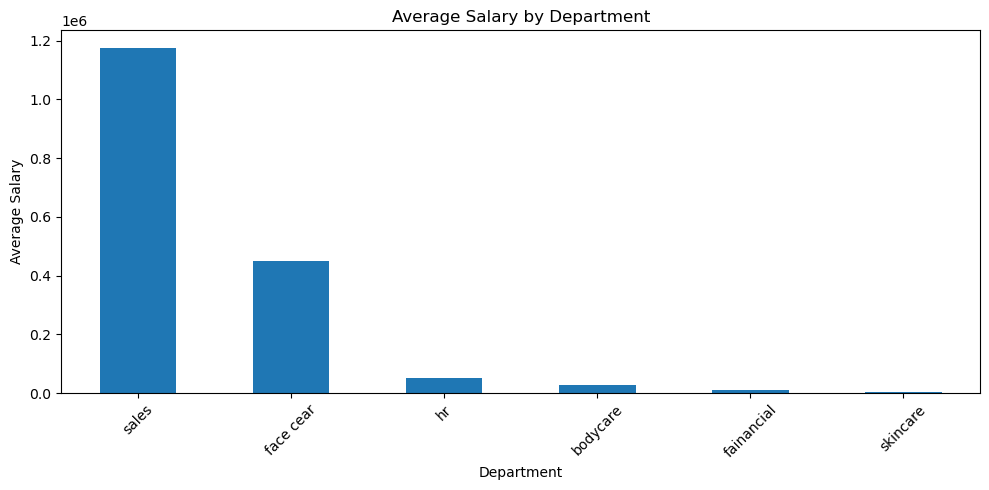

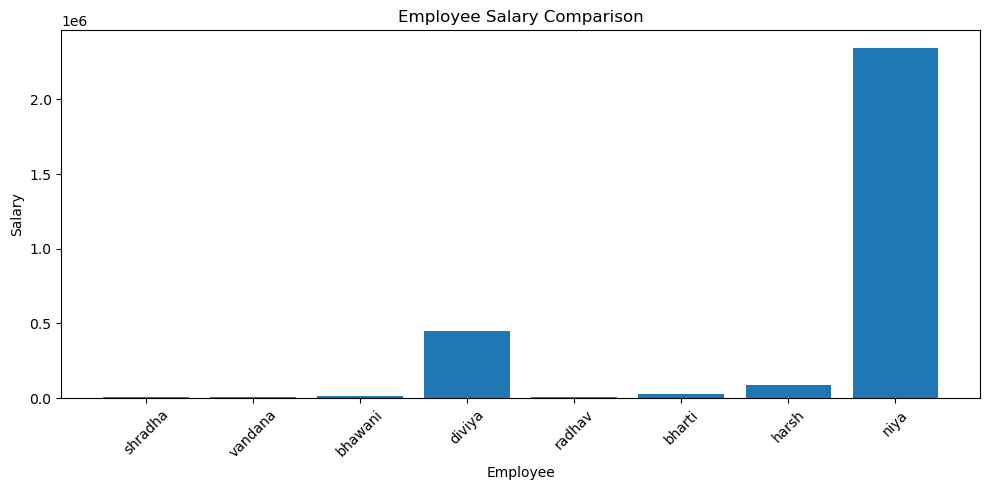

Employee charts created successfully! 📊

[6/6] Creating report...
       PROFESSIONAL EMPLOYEE ANALYSIS REPORT

DATA QUALITY
------------------------------------------------------------
Rows: 8
Columns: 3
Duplicate rows: 0
Missing values: 0

SALARY KPIs
------------------------------------------------------------
Total Salary: ₹2,944,812.00
Average Salary: ₹368,101.50
Highest Salary: ₹2,345,678.00
Lowest Salary: ₹4,500.00

TOP EMPLOYEE
------------------------------------------------------------
Highest-paid employee: niya

DEPARTMENT ANALYSIS
------------------------------------------------------------
Highest average salary department: sales
Average salary: ₹1,175,839.00

BUSINESS INSIGHTS
------------------------------------------------------------
sales has the highest average salary at ₹1,175,839.00.
niya has the highest salary in the dataset.

       Report completed successfully!

🎉 EMPLOYEE ANALYSIS COMPLETED!


,name,department,salary
0,shradha,sales,6000
1,vandana,fainancial,9000
2,bhawani,hr,12000
3,diviya,face cear,450000
4,radhav,skincare,4500
5,bharti,bodycare,27634
6,harsh,hr,90000
7,niya,sales,2345678


In [106]:
universal_agent(employee_test)

In [107]:
def create_sales_summary(df):

    summary = {}

    summary["total_sales"] = float(df["sales"].sum())
    summary["average_sale"] = float(df["sales"].mean())
    summary["highest_sale"] = float(df["sales"].max())
    summary["lowest_sale"] = float(df["sales"].min())

    summary["total_orders"] = int(df["order_id"].nunique())
    summary["total_quantity"] = float(df["quantity"].sum())

    product_sales = (
        df.groupby("product")["sales"]
        .sum()
        .sort_values(ascending=False)
    )

    summary["top_product"] = str(product_sales.index[0])
    summary["top_product_sales"] = float(product_sales.iloc[0])

    region_sales = (
        df.groupby("region")["sales"]
        .sum()
        .sort_values(ascending=False)
    )

    summary["top_region"] = str(region_sales.index[0])
    summary["top_region_sales"] = float(region_sales.iloc[0])

    category_sales = (
        df.groupby("category")["sales"]
        .sum()
        .sort_values(ascending=False)
    )

    summary["top_category"] = str(category_sales.index[0])
    summary["top_category_sales"] = float(category_sales.iloc[0])

    return summary

In [108]:
sales_summary = create_sales_summary(df_sales_clean)

print(sales_summary)

{'total_sales': 1199100.0, 'average_sale': 23982.0, 'highest_sale': 63000.0, 'lowest_sale': 7000.0, 'total_orders': 51, 'total_quantity': 121.0, 'top_product': 'Laptop', 'top_product_sales': 592000.0, 'top_region': 'South', 'top_region_sales': 343500.0, 'top_category': 'Electronics', 'top_category_sales': 1000200.0}


In [109]:
def create_ai_prompt(summary):

    prompt = f"""
You are a professional business data analyst.

Analyze the following sales performance summary:

Total Sales: ₹{summary['total_sales']:,.2f}
Average Sale: ₹{summary['average_sale']:,.2f}
Highest Sale: ₹{summary['highest_sale']:,.2f}
Lowest Sale: ₹{summary['lowest_sale']:,.2f}

Total Orders: {summary['total_orders']}
Total Quantity Sold: {summary['total_quantity']:,.0f}

Top Product: {summary['top_product']}
Top Product Sales: ₹{summary['top_product_sales']:,.2f}

Top Region: {summary['top_region']}
Top Region Sales: ₹{summary['top_region_sales']:,.2f}

Top Category: {summary['top_category']}
Top Category Sales: ₹{summary['top_category_sales']:,.2f}

Provide:

1. Key business insights
2. Possible business opportunities
3. Areas that need attention
4. Three practical recommendations

Keep the response professional and easy for a business client to understand.
"""

    return prompt

In [110]:
ai_prompt = create_ai_prompt(sales_summary)

print(ai_prompt)


You are a professional business data analyst.

Analyze the following sales performance summary:

Total Sales: ₹1,199,100.00
Average Sale: ₹23,982.00
Highest Sale: ₹63,000.00
Lowest Sale: ₹7,000.00

Total Orders: 51
Total Quantity Sold: 121

Top Product: Laptop
Top Product Sales: ₹592,000.00

Top Region: South
Top Region Sales: ₹343,500.00

Top Category: Electronics
Top Category Sales: ₹1,000,200.00

Provide:

1. Key business insights
2. Possible business opportunities
3. Areas that need attention
4. Three practical recommendations

Keep the response professional and easy for a business client to understand.



In [111]:
def generate_smart_insights(summary):

    insights = []

    # Top product
    insights.append(
        f"{summary['top_product']} is the strongest product, "
        f"generating ₹{summary['top_product_sales']:,.2f} in sales."
    )

    # Top region
    insights.append(
        f"{summary['top_region']} is the leading region, "
        f"with sales of ₹{summary['top_region_sales']:,.2f}."
    )

    # Top category
    insights.append(
        f"{summary['top_category']} is the strongest category, "
        f"contributing ₹{summary['top_category_sales']:,.2f}."
    )

    # Quantity
    if summary["total_orders"] > 0:

        avg_quantity = (
            summary["total_quantity"] /
            summary["total_orders"]
        )

        insights.append(
            f"The average quantity per order is "
            f"{avg_quantity:.2f} units."
        )

    # Recommendations
    recommendations = [
        f"Increase marketing focus on {summary['top_product']}.",
        f"Explore growth opportunities in the {summary['top_region']} region.",
        f"Continue monitoring {summary['top_category']} performance."
    ]

    return {
        "insights": insights,
        "recommendations": recommendations
    }

In [112]:
smart_result = generate_smart_insights(sales_summary)

print("BUSINESS INSIGHTS")
print("=" * 60)

for insight in smart_result["insights"]:
    print("•", insight)

print("\nRECOMMENDATIONS")
print("=" * 60)

for recommendation in smart_result["recommendations"]:
    print("•", recommendation)

BUSINESS INSIGHTS
• Laptop is the strongest product, generating ₹592,000.00 in sales.
• South is the leading region, with sales of ₹343,500.00.
• Electronics is the strongest category, contributing ₹1,000,200.00.
• The average quantity per order is 2.37 units.

RECOMMENDATIONS
• Increase marketing focus on Laptop.
• Explore growth opportunities in the South region.
• Continue monitoring Electronics performance.


In [113]:
def create_ai_sales_pdf(
    txt_file="Professional_Sales_Report.txt",
    pdf_file="AI_Sales_Client_Report.pdf"
):

    from reportlab.lib.pagesizes import A4
    from reportlab.platypus import (
        SimpleDocTemplate,
        Paragraph,
        Spacer,
        Image,
        PageBreak
    )
    from reportlab.lib.styles import getSampleStyleSheet

    styles = getSampleStyleSheet()

    document = SimpleDocTemplate(
        pdf_file,
        pagesize=A4
    )

    story = []

    # -------------------------
    # TITLE
    # -------------------------

    story.append(
        Paragraph(
            "<b>AI SALES ANALYSIS REPORT</b>",
            styles["Title"]
        )
    )

    story.append(Spacer(1, 20))

    # -------------------------
    # Existing Report
    # -------------------------

    with open(txt_file, "r", encoding="utf-8") as file:

        lines = file.readlines()

    for line in lines:

        line = line.strip()

        if not line:
            story.append(Spacer(1, 8))

        elif line.startswith("="):
            continue

        elif line.isupper():
            story.append(
                Paragraph(
                    f"<b>{line}</b>",
                    styles["Heading2"]
                )
            )

        else:
            story.append(
                Paragraph(
                    line,
                    styles["BodyText"]
                )
            )

    # -------------------------
    # AI INSIGHTS
    # -------------------------

    story.append(PageBreak())

    story.append(
        Paragraph(
            "<b>AI BUSINESS INSIGHTS</b>",
            styles["Heading1"]
        )
    )

    story.append(Spacer(1, 15))

    for insight in smart_result["insights"]:

        story.append(
            Paragraph(
                "• " + insight,
                styles["BodyText"]
            )
        )

        story.append(Spacer(1, 8))

    # -------------------------
    # RECOMMENDATIONS
    # -------------------------

    story.append(Spacer(1, 15))

    story.append(
        Paragraph(
            "<b>BUSINESS RECOMMENDATIONS</b>",
            styles["Heading1"]
        )
    )

    story.append(Spacer(1, 15))

    for recommendation in smart_result["recommendations"]:

        story.append(
            Paragraph(
                "• " + recommendation,
                styles["BodyText"]
            )
        )

        story.append(Spacer(1, 8))

    # -------------------------
    # CHARTS
    # -------------------------

    story.append(PageBreak())

    story.append(
        Paragraph(
            "<b>SALES VISUAL ANALYSIS</b>",
            styles["Heading1"]
        )
    )

    story.append(Spacer(1, 15))

    charts = [
        ("Sales by Product", "sales_by_product.png"),
        ("Sales by Region", "sales_by_region.png"),
        ("Sales by Category", "sales_by_category.png")
    ]

    for title, image_file in charts:

        story.append(
            Paragraph(
                f"<b>{title}</b>",
                styles["Heading2"]
            )
        )

        story.append(
            Image(
                image_file,
                width=500,
                height=250
            )
        )

        story.append(PageBreak())

    document.build(story)

    print("=" * 60)
    print("AI CLIENT PDF CREATED SUCCESSFULLY! ✅")
    print("=" * 60)
    print(f"File: {pdf_file}")

    return pdf_file

In [114]:
ai_pdf = create_ai_sales_pdf()

AI CLIENT PDF CREATED SUCCESSFULLY! ✅
File: AI_Sales_Client_Report.pdf


In [115]:
import os

print("AI PDF exists:", os.path.exists("AI_Sales_Client_Report.pdf"))

if os.path.exists("AI_Sales_Client_Report.pdf"):
    print(
        "PDF size:",
        os.path.getsize("AI_Sales_Client_Report.pdf"),
        "bytes"
    )

AI PDF exists: True
PDF size: 91671 bytes


In [116]:
def run_complete_agent(file_path):

    print("=" * 70)
    print("       🤖 COMPLETE AI DATA ANALYSIS AGENT")
    print("=" * 70)

    # 1. Load
    print("\n[1/8] Loading dataset...")
    df = load_file(file_path)

    # 2. Clean columns
    print("\n[2/8] Cleaning columns...")
    df = clean_columns(df)

    # 3. Detect dataset
    print("\n[3/8] Detecting dataset...")
    dataset_type = detect_dataset_type(df)

    print(f"Detected Dataset: {dataset_type}")

    # ------------------------------------------------
    # SALES DATASET
    # ------------------------------------------------

    if dataset_type == "Sales Dataset":

        print("\n[4/8] Cleaning sales data...")
        df = clean_sales_data(df)

        print("\n[5/8] Generating KPIs...")
        smart_sales_kpis(df)

        print("\n[6/8] Generating business insights...")
        sales_business_insights(df)

        # AI summary
        sales_summary = create_sales_summary(df)

        smart_result = generate_smart_insights(
            sales_summary
        )

        print("\n[7/8] Creating charts...")
        save_sales_charts(df)

        print("\n[8/8] Creating AI client report...")
        create_sales_report(df)
        create_ai_sales_pdf()

        print("\n" + "=" * 70)
        print("       🎉 COMPLETE SALES ANALYSIS DONE!")
        print("=" * 70)

        print("\nGenerated files:")
        print("✅ Professional_Sales_Report.txt")
        print("✅ AI_Sales_Client_Report.pdf")
        print("✅ sales_by_product.png")
        print("✅ sales_by_region.png")
        print("✅ sales_by_category.png")

    # ------------------------------------------------
    # EMPLOYEE DATASET
    # ------------------------------------------------

    elif dataset_type == "Employee Dataset":

        print("\n[4/8] Running employee analysis...")
        automatic_kpis(df)

        print("\n[5/8] Generating employee insights...")
        automatic_insights(df)

        print("\n[6/8] Creating employee charts...")
        create_employee_charts(df)

        print("\n[7/8] Creating employee report...")
        create_employee_report(df)

        print("\n[8/8] Employee analysis completed!")

        print("\n" + "=" * 70)
        print("       🎉 COMPLETE EMPLOYEE ANALYSIS DONE!")
        print("=" * 70)

    # ------------------------------------------------
    # UNKNOWN DATASET
    # ------------------------------------------------

    else:

        print("\n[4/8] Running general dataset analysis...")
        general_dataset_analysis(df)

        print("\n[5/8] General insights completed.")
        print("\n[6/8] Specialized charts not available.")
        print("\n[7/8] Specialized report not available.")
        print("\n[8/8] General analysis completed!")

    return df

In [117]:
final_result = run_complete_agent("14.xlsx")

       🤖 COMPLETE AI DATA ANALYSIS AGENT

[1/8] Loading dataset...
File loaded successfully! ✅
Rows: 51
Columns: 78

[2/8] Cleaning columns...
Column names cleaned successfully! ✅
Clean columns:
['order_id', 'product', 'category', 'region', 'sales', 'quantity', 'unnamed: 6', 'total sales', 'average sales', 'highest sales', 'lowest sales', 'electronics category total sales', 'furniture category total sales', 'north region total sales', 'if', 'product laptop total entries', 'south region average sales', 'total quantity', 'unnamed: 18', 'unnamed: 19', 'unnamed: 20', 'unnamed: 21', 'unnamed: 22', 'unnamed: 23', 'unnamed: 24', 'unnamed: 25', 'unnamed: 26', 'unnamed: 27', 'unnamed: 28', 'unnamed: 29', 'unnamed: 30', 'unnamed: 31', 'unnamed: 32', 'unnamed: 33', 'unnamed: 34', 'unnamed: 35', 'unnamed: 36', 'unnamed: 37', 'unnamed: 38', 'unnamed: 39', 'unnamed: 40', 'unnamed: 41', 'unnamed: 42', 'unnamed: 43', 'unnamed: 44', 'unnamed: 45', 'unnamed: 46', 'unnamed: 47', 'unnamed: 48', 'unnamed: 

In [118]:
final_result = run_complete_agent("14.xlsx")

       🤖 COMPLETE AI DATA ANALYSIS AGENT

[1/8] Loading dataset...
File loaded successfully! ✅
Rows: 51
Columns: 78

[2/8] Cleaning columns...
Column names cleaned successfully! ✅
Clean columns:
['order_id', 'product', 'category', 'region', 'sales', 'quantity', 'unnamed: 6', 'total sales', 'average sales', 'highest sales', 'lowest sales', 'electronics category total sales', 'furniture category total sales', 'north region total sales', 'if', 'product laptop total entries', 'south region average sales', 'total quantity', 'unnamed: 18', 'unnamed: 19', 'unnamed: 20', 'unnamed: 21', 'unnamed: 22', 'unnamed: 23', 'unnamed: 24', 'unnamed: 25', 'unnamed: 26', 'unnamed: 27', 'unnamed: 28', 'unnamed: 29', 'unnamed: 30', 'unnamed: 31', 'unnamed: 32', 'unnamed: 33', 'unnamed: 34', 'unnamed: 35', 'unnamed: 36', 'unnamed: 37', 'unnamed: 38', 'unnamed: 39', 'unnamed: 40', 'unnamed: 41', 'unnamed: 42', 'unnamed: 43', 'unnamed: 44', 'unnamed: 45', 'unnamed: 46', 'unnamed: 47', 'unnamed: 48', 'unnamed: 

In [119]:
import os

print("FINAL PDF:", os.path.exists("AI_Sales_Client_Report.pdf"))
print("PDF SIZE:", os.path.getsize("AI_Sales_Client_Report.pdf"), "bytes")

FINAL PDF: True
PDF SIZE: 91671 bytes
